In [1]:
_MERKZETTEL = {}


def merke(schluessel, wert):
    """Haelt ein Ergebnis fuer den Fliesstext fest und gibt es zurueck."""
    _MERKZETTEL[schluessel] = wert
    return wert

# Assoziationsanalyse: Welche Wege gehören zusammen?

**Verfahren:** Assoziationsanalyse (unüberwacht — das Ergebnis sind Regeln, keine Zahlen und keine Gruppen)  |  **Geschäftsfrage:** Zwischen welchen Stationen gibt es systematische Ströme, und wann?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/05_Assoziation_Wege_im_Netz.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

## Das dritte Gesicht des maschinellen Lernens

| Notebook | Ergebnis des Verfahrens |
|---|---|
| 1 und 2 | eine **Vorhersage** je Objekt (Dauer, Ausfallrisiko) |
| 3 | eine **Gruppe** je Objekt (Stationstyp, Kundensegment) |
| **5** | **Regeln über Zusammenhänge** — keine Vorhersage, keine Gruppe |

> **Womit wir hier rechnen.** Die VeloCity-Daten sind **synthetisch** — erzeugt für diese
> Fallstudie, nicht in Würzburg gemessen. Die Verfahren, die Fallstricke und die
> Entscheidungswege sind echt; die Zahlen beschreiben kein reales Verkehrsaufkommen.
> Wo unten „die Ströme dieser Stadt" steht, ist immer der Datensatz gemeint.

Die Assoziationsanalyse stammt aus dem Handel und heißt dort **Warenkorbanalyse**: Welche
Artikel liegen zusammen im Einkaufswagen? Das berühmte (und wahrscheinlich erfundene)
Beispiel ist *Windeln und Bier*.

Übertragen auf VeloCity: **Eine Fahrt ist ein Warenkorb.** Darin liegen die Startstation,
die Zielstation, die Tageszeit, der Wochentag, der Radtyp. Die Frage lautet: Was liegt
regelmäßig zusammen im selben Korb?

> **Warum wir das ohne Bibliothek rechnen.** Für Assoziationsregeln gibt es fertige
> Pakete (`mlxtend`, `apyori`). Wir rechnen die drei Kennzahlen hier von Hand — sie
> bestehen aus je einer Division, und wer sie einmal selbst gerechnet hat, fällt später
> nicht auf eine Regel herein, die nur nach etwas aussieht.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Die Disposition weiß, dass sie morgens umverteilen muss. Sie weiß nicht, **wohin**.

### Die Ausgangslage

Aus Notebook 3 wissen wir, welche **Typen** von Stationen es gibt. Was wir nicht wissen:
**welche Station sich zugunsten welcher anderen leert.** Der Transporter fährt morgens
los und verteilt nach Gefühl um.

Die Frage ist also nicht mehr „wie viele Räder“ (das war Notebook 4), sondern
**„von wo nach wo“**.

### Warum Assoziationsanalyse und nicht einfach eine Kreuztabelle?

Eine Kreuztabelle Start × Ziel könnte man auch bauen. Sie hätte aber ein Problem: Sie
zeigt **absolute Häufigkeiten**, und die größten Zahlen stehen dort, wo einfach am
meisten los ist. Der Hauptbahnhof taucht überall oben auf — nicht weil er besondere
Beziehungen hat, sondern weil er groß ist.

Die Assoziationsanalyse rechnet das heraus. Ihre dritte Kennzahl, der **Lift**, fragt
genau das: *Kommt diese Kombination häufiger vor, als man bei Unabhängigkeit erwarten
würde?*

### Die drei Kennzahlen — an einem Beispiel aus dem Handel

Regel: **{Brot} → {Butter}**

| Kennzahl | Frage | Rechnung |
|---|---|---|
| **Support** | Wie oft kommt die Kombination überhaupt vor? | Körbe mit Brot *und* Butter ÷ alle Körbe |
| **Konfidenz** | Wenn Brot drin ist — wie oft dann auch Butter? | Körbe mit beidem ÷ Körbe mit Brot |
| **Lift** | Ist das mehr, als der Zufall hergäbe? | Konfidenz ÷ Anteil aller Körbe mit Butter |

**Lift = 1** heißt: kein Zusammenhang. **Lift = 2**: doppelt so häufig wie erwartet.
**Lift < 1**: die beiden meiden einander.

### Ein Zusatz, der bei uns nötig ist: der Lift **im Kontext**

Im Supermarkt gibt es nur einen Korb. Bei uns hat jede Fahrt einen **Kontext** — Werktag
oder frei, und eines von vier Zeitfenstern. Und die Ziele sind je nach Kontext ganz
verschieden beliebt: Der Campus ist werktags früh ein häufiges Ziel und sonntags abends
fast keines.

Rechnet man den Lift gegen den Anteil über **alle** Fahrten, misst man deshalb zwei Dinge
auf einmal: den Zusammenhang *und* den Umstand, dass morgens andere Ziele gefragt sind als
abends. Wir rechnen deshalb gegen die Basisrate **im selben Kontext**:

| | Nenner der Division | Was er misst |
|---|---|---|
| klassischer Lift | Anteil des Ziels an **allen** Fahrten | Zusammenhang **und** Kontexteffekt, vermischt |
| **kontextbedingter Lift** ← unsere Wahl | Anteil des Ziels **im selben Kontext** | nur den Zusammenhang, bei gleichem Kontext |

In beiden Fällen ist der Zähler derselbe: die Konfidenz, also der Anteil der Fahrten ab
dieser Startstation in diesem Kontext, die an diesem Ziel enden.

Der Unterschied ist nicht klein. Für die **supportstärkste** Regel dieses Notebooks —
Werktag · früh (0-10) von „Juliuspromenade" nach „Grombühl Klinikum" — liegt der klassische Lift bei
**2,78**, der kontextbedingte bei **1,77**. Ein
guter Teil des klassischen Werts kommt also gar nicht von der Verbindung, sondern daher,
dass das Ziel in diesem Zeitfenster ohnehin gefragt ist.

**Wir weisen ab hier ausschließlich den kontextbedingten Lift aus**, und die Schwelle in
den Erfolgskriterien bezieht sich auf ihn. Beide Werte stehen in Phase 4 nebeneinander,
damit der Abstand sichtbar bleibt.

### Die Erfolgskriterien

Eine Regel ist für die Disposition **nur dann brauchbar**, wenn alle drei zutreffen:

| | Kriterium | Schwelle | Warum |
|---|---|---|---|
| 1 | **Support** | mindestens 1 % der **Warenkörbe** | Für eine Regel, die zwanzig Fahrten im Jahr betrifft, fährt kein Transporter |
| 2 | **kontextbedingter Lift** | mindestens 1,3 | Darunter ist es Zufall oder schlicht Größe |
| 3 | **Ziel ist eine konkrete Station** | Start ≠ Ziel, und das Ziel ist keine freie Abstellung | eine Rundtour verschiebt kein Rad; „frei abgestellt“ ist kein Ort, den man anfahren kann |

**Kriterium 3 wird in Phase 5 als Code geprüft**, nicht als Absichtserklärung. Ein
Kriterium, das nur im Text steht, ist keines.

> **Und es heißt bewusst nicht „handlungsfähig".** Geprüft wird ausschließlich, ob das
> Ziel eine anfahrbare Station ist — **technische Adressierbarkeit**. Ob Menge, Bestand,
> Kapazität und Kosten eine Transporterfahrt rechtfertigen, sagt dieses Kriterium nicht
> und kann es nicht sagen. Eine frühere Fassung nannte es „handlungsfähig" und
> versprach damit mehr, als sie prüfte.

**Kriterium 1 ist das, das am meisten Regeln aussortiert** — und zwar gerade die mit den
spektakulärsten Lift-Werten. Wir werden das gleich sehen. Ob es dabei das Richtige misst,
ist eine eigene Frage; sie wird in Phase 5 gestellt und fällt unangenehm aus.

### Zwei Produkte, zwei Kriteriensätze

Dieses Notebook kann **zwei verschiedene Dinge** abliefern, und sie brauchen verschiedene
Nachweise. Beide werden hier festgelegt, vor der ersten Rechnung:

**Produkt A — die automatische Umverteilungsregel.** Der Transporter fährt, weil eine
Regel es sagt. Dafür reichen die drei Kriterien oben **nicht**; hinzu kommt eine vierte,
wirtschaftliche Hürde:

| | Kriterium | Schwelle |
|---|---|---|
| **A4** | Der Wert der Fahrten, die eine Regel je Umsetzrunde betrifft, muss die Kosten dieser Runde übersteigen | 35 € je Runde gegen 2,20 € je Fahrt — **beides gesetzte Szenarioannahmen**, keine gemessenen Kosten |

**Produkt B — der Dispositionshinweis.** Kein Transportauftrag, sondern ein Satz in der
Dispositionsansicht, den ein Mensch liest und bewertet. Ein Hinweis darf schwächer belegt
sein als ein Auftrag — aber nicht beliebig:

| | Kriterium | Warum |
|---|---|---|
| **B1** | Die Regel hält in einem **Bestätigungszeitraum**, den die Suche nicht gesehen hat | Ein Muster aus dem Suchzeitraum ist eine Beschreibung, kein Befund |
| **B2** | Die Anzeige nennt die **Größenordnung** — Fahrten je Werktag — direkt neben der Regel | Ohne sie liest jemand „Pendelstrom" und schickt einen Transporter |
| **B3** | Kein automatischer Auftrag; die Entscheidung trifft ein Mensch | Für die Automatik fehlt A4 |
| **B4** | Begleitende Auswertungen (Stationssalden, Abstell-Hotspots) tragen im Dateikopf und in der Ansicht das Wort **explorativ** | Sie hatten nie vorab gesetzte Kriterien |

> **Warum das hier steht und nicht in Phase 6.** Eine frühere Fassung hat in Phase 5
> geschrieben „freigegeben ist nichts" und in Phase 6 „freigegeben als Entscheidungshilfe".
> Beides stand nebeneinander im selben Notebook. Der Grund war nicht Nachlässigkeit,
> sondern ein fehlendes Produkt: Die Entscheidungshilfe war nie als eigenes Produkt mit
> eigenen Kriterien definiert, also gab es auch keinen Maßstab, an dem sie freigegeben
> oder verweigert werden konnte. **Ein Produkt ohne Kriterien kann man weder freigeben
> noch ablehnen — man kann nur darüber streiten.**

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Was liegt in unseren Warenkörben, und wie häufig ist jedes Ding für sich?

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Die Adresse zeigt auf den Zweig 'main' - der sich aendern kann. Fuer eine
# Auswertung, die spaeter exakt reproduzierbar sein muss, gehoert hier ein
# fester Commit-Hash statt 'main' hinein.
BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/17810afc24029bf82bafa0cbfb480810e6a98e3c/analytics/")
pd.set_option("display.width", 160)

fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit"])
stationen = pd.read_csv(BASIS + "station.csv")
feiertage = set(pd.read_csv(BASIS + "feiertage.csv").datum)

k = fahrten[fahrten.status == "abgeschlossen"].copy()
namen = stationen.set_index("station_id").name
k["start"] = k.start_station_id.map(namen)
# FREI ABGESTELLT IST EIN ZIEL, KEIN FEHLENDER WERT.
# Rund ein Fuenftel der Fahrten endet nicht an einer Station, sondern irgendwo
# im Geschaeftsgebiet - die Kundenwebsite wirbt damit ("ueberall in der roten
# Umrandung, ohne Zuschlag"). Wer diese Zeilen als fehlende Werte behandelt,
# wirft ein Fuenftel der Daten weg, ohne es zu merken, und alle Regeln
# verlieren ein Fuenftel ihrer Belege.
k["ziel"] = k.end_station_id.map(namen).fillna("frei abgestellt")
k["stunde"] = k.startzeit.dt.hour
k["ist_frei"] = ((k.startzeit.dt.dayofweek >= 5)
                 | k.startzeit.dt.strftime("%Y-%m-%d").isin(feiertage))

print(f"{len(k):,d} Fahrten als 'Warenkörbe'".replace(",", "."))
print("\nWie häufig ist jede Station als ZIEL? (das sind die Basisraten für den Lift)")
basis_ziel = k.ziel.value_counts(normalize=True)
print((basis_ziel * 100).round(1).to_string())

# Die Zahlen des Fliesstextes stammen von hier.
_nur_stationen = basis_ziel.drop("frei abgestellt", errors="ignore")
merke("anteil_frei", basis_ziel.get("frei abgestellt", 0))
merke("station_min", _nur_stationen.min()); merke("station_max", _nur_stationen.max())
# Dieselbe Station, zwei Nenner: ueber alle Fahrten und im Kontext.
_kontext = k[(~k.ist_frei) & (k.stunde < 10)]
_beispiel = _nur_stationen.idxmax()
merke("beispiel_station", _beispiel)
merke("beispiel_gesamt", _nur_stationen[_beispiel])
merke("beispiel_kontext", (_kontext.ziel == _beispiel).mean())
print(f"\nDerselbe Ort, zwei Nenner - '{_beispiel}':")
print(f"   ueber alle Fahrten          {_nur_stationen[_beispiel]:.1%}")
print(f"   werktags frueh (0-10 Uhr)   {(_kontext.ziel == _beispiel).mean():.1%}")

104.401 Fahrten als 'Warenkörbe'

Wie häufig ist jede Station als ZIEL? (das sind die Basisraten für den Lift)
ziel
frei abgestellt           16.5
Hauptbahnhof              11.8
Hubland Campus            11.4
Grombühl Klinikum         10.4
Dom                        9.0
Universität Sanderring     8.7
Residenz                   8.5
Sanderau                   7.0
Zellerau                   5.9
Juliuspromenade            5.7
Marktplatz                 5.1

Derselbe Ort, zwei Nenner - 'Hauptbahnhof':
   ueber alle Fahrten          11.8%
   werktags frueh (0-10 Uhr)   18.8%


**Diese Tabelle zeigt den Maßstab — aber nicht den, gegen den wir rechnen werden.** Zwei
Dinge fallen auf. **„Frei abgestellt“ ist mit Abstand das häufigste Ziel** —
16,5 % der Fahrten enden so. Und die zehn Stationen liegen eng
beieinander, zwischen 5,1 % und 11,8 %; sie sind also
ähnlich beliebt.

> **Wichtig für später:** Das sind die Anteile über **alle** Fahrten. Der Lift, den wir ab
> Phase 4 ausweisen, rechnet gegen die Basisrate **im jeweiligen Kontext** — und die
> weicht davon deutlich ab. Werktags früh ist „Hauptbahnhof" nicht in
> 11,8 % der Fahrten das Ziel, sondern in 18,8 %. Wer
> die Tabelle hier für die Lift-Grundlage hält,
> rechnet mit den falschen Nennern.

### 2.1 Der triviale Zusammenhang, den man zuerst finden muss

In [3]:
print(f"Anteil der Fahrten, die frei abgestellt enden: {(k.ziel == 'frei abgestellt').mean():.1%}")
print()
print("Wo endet es frei? (Anteil je Startstation)")
je_start = k.assign(f=(k.ziel == "frei abgestellt")).groupby("start").f.mean()
print((je_start.sort_values(ascending=False) * 100).round(1).to_string())

angedockt = k[k.ziel != "frei abgestellt"]
rundtour = (angedockt.start == angedockt.ziel).mean()
print()
merke("anteil_rundtouren", rundtour)
print(f"Anteil Rundtouren unter den angedockten Fahrten: {rundtour:.1%}")
je_station = angedockt.assign(r=(angedockt.start == angedockt.ziel)).groupby("start").r.mean()
print((je_station.sort_values(ascending=False) * 100).round(1).to_string())

Anteil der Fahrten, die frei abgestellt enden: 16.5%

Wo endet es frei? (Anteil je Startstation)
start
Residenz                  21.1
Dom                       21.0
Hauptbahnhof              17.1
Universität Sanderring    16.9
Juliuspromenade           16.0
Hubland Campus            15.6
Marktplatz                15.1
Sanderau                  14.3
Zellerau                  14.3
Grombühl Klinikum         14.0

Anteil Rundtouren unter den angedockten Fahrten: 12.6%
start
Dom                       28.4
Residenz                  28.3
Hubland Campus            12.7
Hauptbahnhof              12.3
Universität Sanderring    11.1
Sanderau                   9.1
Zellerau                   7.8
Grombühl Klinikum          7.6
Marktplatz                 6.7
Juliuspromenade            6.6


**Zwei Befunde stehen hier, und beide sind wichtig.**

**Erstens:** Rund ein Fünftel der Fahrten endet **nicht an einer Station**. Das ist kein
Datenmangel, sondern ein beworbenes Merkmal — man darf das Rad überall im Geschäftsgebiet
abstellen. Ein Analyst, der `end_station_id` als Pflichtfeld behandelt und die Zeilen
verwirft, verliert ein Fünftel seiner Belege und merkt es nicht. **Wir behandeln „frei
abgestellt“ deshalb als eigenes Ziel.** Die Tabelle darüber zeigt, dass der Anteil je nach
Startstation schwankt — er ist ein Merkmal der Gegend, nicht des Zufalls.

**Zweitens:** 12,6 % der angedockten Fahrten enden dort, wo sie
begannen. Das ist die **häufigste triviale Start-Ziel-Gleichheit**, und sie wird jede
Regelliste anführen, wenn man sie nicht ausschließt.

**Nützlich ist er trotzdem nicht.** Eine Rundtour verschiebt kein einziges Rad; für die
Disposition ist sie ein Nullsummenvorgang. Wir schließen Rundtouren deshalb aus der
Regelsuche aus — **ausdrücklich und begründet**, nicht heimlich.

> Das ist ein wiederkehrendes Muster bei Assoziationsanalysen: **Die stärkste Regel ist
> fast immer die, die man schon kannte.** Im Supermarkt ist es „wer Milch kauft, kauft
> Milch derselben Marke“. Der Wert des Verfahrens beginnt erst darunter.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Aus jeder Fahrt wird ein Warenkorb mit Zeitfenster und Tagesart.

In [4]:
# Zeitfenster statt Stunden: Mit 24 Kontexten statt 4 verteilen sich dieselben
# Fahrten auf sechsmal so viele Kombinationen - jede einzelne hat dann
# entsprechend weniger Belege. (Wie viel genau, haengt davon ab, wie
# ungleich die Fahrten ueber die Stunden liegen; gleichmaessig sind sie
# nicht.) Vier Fenster halten die Regeln belegbar und entsprechen dem,
# wonach die Disposition ohnehin plant.
#
# Diese vier Grenzen sind GESETZT, nicht gefunden. Ob andere Grenzen
# stabilere Regeln ergaeben, ist nicht geprueft - das steht in den offenen
# Fragen.
# Die Grenzen muessen die 24 Stunden LUECKENLOS abdecken - sonst faellt die
# Nachtstunde stillschweigend aus der Analyse. Das erste Fenster beginnt
# deshalb bei 0 Uhr und heisst auch so; ein Etikett "5-10" ueber einem
# Fenster, das um Mitternacht anfaengt, waere schlicht falsch.
GRENZEN = [0, 10, 15, 20, 24]
BEZEICHNUNGEN = ["früh (0-10)", "mittag (10-15)", "abend (15-20)", "spät (20-24)"]

k["fenster"] = pd.cut(k.stunde, GRENZEN, labels=BEZEICHNUNGEN, right=False)
k["tagesart"] = np.where(k.ist_frei, "frei", "Werktag")

# Rundtouren ausgeschlossen (siehe Phase 2). Die frei abgestellten Fahrten
# bleiben drin - sie sind ein Ziel wie jedes andere.
koerbe = k[k.start != k.ziel].copy()
print(f"Warenkörbe für die Regelsuche: {len(koerbe):,d}".replace(",", "."))
# DER NENNER DES SUPPORTS HAT EINEN NAMEN, UND ER IST NICHT "alle Fahrten".
# Gezaehlt wird gegen die Warenkoerbe - abgeschlossene Fahrten OHNE Rundtouren.
# Der Unterschied ist kein Rundungsfehler.
merke("koerbe_n", len(koerbe)); merke("fahrten_n", len(k))
merke("koerbe_anteil", len(koerbe) / len(k))
print(f"   Das sind {len(koerbe) / len(k):.1%} der {len(k):,d} abgeschlossenen "
      f"Fahrten.".replace(",", "."))
print("   Der Support misst gegen DIESE Menge, nicht gegen alle Fahrten -")
print("   die Rundtouren sind vorher ausgeschieden.")
print("\nVerteilung über die Zeitfenster:")
print(pd.crosstab(koerbe.fenster, koerbe.tagesart, margins=True).to_string())

Warenkörbe für die Regelsuche: 93.370
   Das sind 89.4% der 104.401 abgeschlossenen Fahrten.
   Der Support misst gegen DIESE Menge, nicht gegen alle Fahrten -
   die Rundtouren sind vorher ausgeschieden.

Verteilung über die Zeitfenster:
tagesart        Werktag   frei    All
fenster                              
früh (0-10)       21499   4438  25937
mittag (10-15)    19833   8841  28674
abend (15-20)     23107   8491  31598
spät (20-24)       4648   2513   7161
All               69087  24283  93370


---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Support, Konfidenz und Lift — drei Divisionen, von Hand gerechnet.

In [5]:
from scipy.stats import fisher_exact

# Die Suchgrenze steht EINMAL - sie ist ein Filter vor jedem Kriterium und
# entscheidet mit, was ueberhaupt sichtbar wird. Die beiden Erfolgskriterien
# aus Phase 1 stehen daneben, ebenfalls je einmal.
MINDEST_SUPPORT = 0.005
K1_SUPPORT = 0.01      # Erfolgskriterium 1: Anteil aller Warenkoerbe
K2_LIFT = 1.3          # Erfolgskriterium 2: kontextbedingter Lift


def regeln_finden(koerbe, kontextspalten, mindest_support=MINDEST_SUPPORT):
    """Findet Regeln {Start, Kontext} -> {Ziel} und rechnet die Kennzahlen.

    Bewusst ohne Bibliothek: jede Zeile hier entspricht einer Zeile in der
    Definition aus Phase 1. Wir geben BEIDE Lift-Varianten aus, damit der
    Unterschied zwischen ihnen sichtbar bleibt und niemand die eine Zahl
    mit der Definition der anderen erklaert.
    """
    n = len(koerbe)
    basis_global = koerbe.ziel.value_counts(normalize=True)
    zeilen = []
    for kontext, teil in koerbe.groupby(kontextspalten, observed=True):
        if not isinstance(kontext, tuple):
            kontext = (kontext,)
        # Basisrate des Ziels IM SELBEN KONTEXT - sonst vergliche man
        # Aepfel mit Birnen (Werktagsziele gegen Wochenendziele).
        basis = teil.ziel.value_counts(normalize=True)
        n_kontext = len(teil)
        for start, gruppe in teil.groupby("start", observed=True):
            n_start = len(gruppe)
            for ziel, n_beide in gruppe.ziel.value_counts().items():
                support = n_beide / n
                if support < mindest_support:
                    continue
                konfidenz = n_beide / n_start
                # Vierfeldertafel im Kontext: fuehrt dieser Start haeufiger
                # zu diesem Ziel als alle anderen Starts im selben Fenster?
                nicht_ziel_hier = n_start - n_beide
                ziel_woanders = int((teil.ziel == ziel).sum()) - n_beide
                rest = n_kontext - n_start - ziel_woanders
                p = fisher_exact([[n_beide, nicht_ziel_hier],
                                  [ziel_woanders, rest]], alternative="greater")[1]
                zeilen.append({
                    "Kontext": " · ".join(map(str, kontext)),
                    "wenn Start": start, "dann Ziel": ziel,
                    "Fahrten": n_beide,
                    "Support": support,
                    "Konfidenz": konfidenz,
                    "Lift (Kontext)": konfidenz / basis[ziel],
                    "Lift (klassisch)": konfidenz / basis_global[ziel],
                    "p": p,
                })
    return pd.DataFrame(zeilen)

regeln = regeln_finden(koerbe, ["tagesart", "fenster"])

# KRITERIUM 3 ALS CODE - UND EHRLICH BENANNT.
#
# Geprueft wird genau eines: ob das Ziel eine Station ist. "-> frei
# abgestellt" ist kein Ort, den ein Transporter anfaehrt. Rundtouren sind
# schon in Phase 3 ausgeschlossen.
#
# Die Spalte hiess frueher "handlungsfaehig". Das war zu viel versprochen:
# Ob eine Regel eine Transporterfahrt RECHTFERTIGT, haengt an Menge,
# Bestand, Kapazitaet und Kosten - nichts davon steht hier. Der Name sagt
# jetzt, was die Zeile prueft.
regeln["ziel_ist_station"] = regeln["dann Ziel"] != "frei abgestellt"
print(f"{len(regeln)} Regeln mit mindestens 0,5 % Support gefunden, davon "
      f"{int(regeln['ziel_ist_station'].sum())} mit einer Station als Ziel.\n")

anzeige = ["Kontext", "wenn Start", "dann Ziel", "Fahrten", "Support",
           "Konfidenz", "Lift (Kontext)", "Lift (klassisch)"]
top = regeln.nlargest(10, "Lift (Kontext)")
print("Die zehn Regeln mit dem höchsten kontextbedingten Lift:")
print(top[anzeige].round({"Support": 4, "Konfidenz": 3,
                          "Lift (Kontext)": 2, "Lift (klassisch)": 2}).to_string(index=False))
print("\nDieselben zehn Regeln, klassischer Lift daneben: er ist durchweg groesser,")
print("weil er den Kontexteffekt mitzaehlt. Beide Spalten beschreiben dieselben Fahrten.")

43 Regeln mit mindestens 0,5 % Support gefunden, davon 33 mit einer Station als Ziel.

Die zehn Regeln mit dem höchsten kontextbedingten Lift:
                 Kontext        wenn Start         dann Ziel  Fahrten  Support  Konfidenz  Lift (Kontext)  Lift (klassisch)
   frei · mittag (10-15)               Dom   Juliuspromenade      514   0.0055      0.238            1.89              4.22
Werktag · mittag (10-15)   Juliuspromenade Grombühl Klinikum      631   0.0068      0.214            1.79              1.99
   Werktag · früh (0-10)   Juliuspromenade Grombühl Klinikum     1236   0.0132      0.300            1.77              2.78
Werktag · mittag (10-15) Grombühl Klinikum      Hauptbahnhof      593   0.0064      0.236            1.77              1.92
 Werktag · abend (15-20) Grombühl Klinikum      Hauptbahnhof      784   0.0084      0.229            1.64              1.86
   Werktag · früh (0-10) Grombühl Klinikum      Hauptbahnhof     1098   0.0118      0.295            1.55        

### Die Zahlen einer einzelnen Regel nachrechnen

Damit klar ist, dass hier keine Magie stattfindet, rechnen wir eine Regel von Hand nach.

In [6]:
beispiel = regeln.nlargest(1, "Lift (Kontext)").iloc[0]
teil = koerbe[(koerbe.tagesart == beispiel.Kontext.split(" · ")[0])
              & (koerbe.fenster == beispiel.Kontext.split(" · ")[1])]
n_gesamt = len(koerbe)
n_start = int((teil.start == beispiel["wenn Start"]).sum())
n_beide = int(((teil.start == beispiel["wenn Start"]) & (teil.ziel == beispiel["dann Ziel"])).sum())
basisrate = (teil.ziel == beispiel["dann Ziel"]).mean()

print(f"Regel:  WENN Start = {beispiel['wenn Start']}  ({beispiel.Kontext})")
print(f"        DANN Ziel  = {beispiel['dann Ziel']}\n")
def zeile(text, zahl):
    print(f"  {text:<46s}{f'{zahl:,d}'.replace(',', '.'):>9s}")

zeile("Fahrten insgesamt (alle Kontexte)", n_gesamt)
zeile(f"Fahrten ab {beispiel['wenn Start']} in diesem Kontext", n_start)
zeile(f"davon nach {beispiel['dann Ziel']}", n_beide)
print()
print(f"  Support    = {n_beide} / {n_gesamt}   = {n_beide/n_gesamt:.4f}  ({n_beide/n_gesamt:.2%})")
print(f"  Konfidenz  = {n_beide} / {n_start}      = {n_beide/n_start:.3f}   ({n_beide/n_start:.1%})")
basis_alle = (koerbe.ziel == beispiel["dann Ziel"]).mean()
print(f"  Basisrate im Kontext  = Anteil der Fahrten IN DIESEM FENSTER nach "
      f"{beispiel['dann Ziel']}  = {basisrate:.3f}")
print(f"  Basisrate insgesamt   = Anteil ALLER Fahrten nach "
      f"{beispiel['dann Ziel']}  = {basis_alle:.3f}")
print()
print(f"  Lift (Kontext)   = {n_beide/n_start:.3f} / {basisrate:.3f} "
      f"= {(n_beide/n_start)/basisrate:.2f}   <- diesen weisen wir aus")
print(f"  Lift (klassisch) = {n_beide/n_start:.3f} / {basis_alle:.3f} "
      f"= {(n_beide/n_start)/basis_alle:.2f}")
print()
print("  Die beiden Zahlen beschreiben dieselben Fahrten. Der Unterschied ist der")
print("  Nenner: einmal 'wie beliebt ist das Ziel jetzt', einmal 'wie beliebt ist es")
print("  ueberhaupt'. Wer den einen Wert nennt und den anderen erklaert, taeuscht -")
print("  meist sich selbst.")

Regel:  WENN Start = Dom  (frei · mittag (10-15))
        DANN Ziel  = Juliuspromenade

  Fahrten insgesamt (alle Kontexte)                93.370
  Fahrten ab Dom in diesem Kontext                  2.161
  davon nach Juliuspromenade                          514

  Support    = 514 / 93370   = 0.0055  (0.55%)
  Konfidenz  = 514 / 2161      = 0.238   (23.8%)
  Basisrate im Kontext  = Anteil der Fahrten IN DIESEM FENSTER nach Juliuspromenade  = 0.126
  Basisrate insgesamt   = Anteil ALLER Fahrten nach Juliuspromenade  = 0.056

  Lift (Kontext)   = 0.238 / 0.126 = 1.89   <- diesen weisen wir aus
  Lift (klassisch) = 0.238 / 0.056 = 4.22

  Die beiden Zahlen beschreiben dieselben Fahrten. Der Unterschied ist der
  Nenner: einmal 'wie beliebt ist das Ziel jetzt', einmal 'wie beliebt ist es
  ueberhaupt'. Wer den einen Wert nennt und den anderen erklaert, taeuscht -
  meist sich selbst.


---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Die Regeln mit dem höchsten Lift sind nicht die nützlichsten. Jetzt kommen die Kriterien aus Phase 1 zum Einsatz.

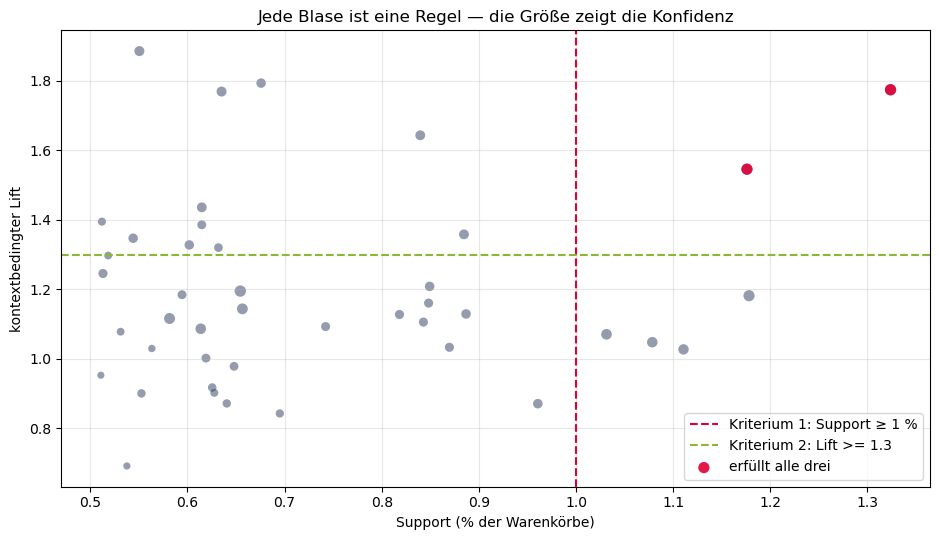

Regeln insgesamt:                 43
K1  Support ≥ 1%:                6
K2  Lift (Kontext) ≥ 1.3:       13
K3  Ziel ist eine Station:        33
alle drei zusammen:               2

A4 - OBERGRENZENRECHNUNG JE REGEL (keine Wirkungsmessung)
   Angenommen: eine Umsetzrunde kostet 35 EUR,
   eine verhinderte Fahrt bringt 2.20 EUR. Beides gesetzt.
   Gerechnet wird der EXTREMFALL: jede beobachtete Regelfahrt waere
   ohne Umverteilung verloren und durch die Runde gerettet.
   Rentabel ab 16 zusaetzlichen Fahrten je Runde.

   Regel                                                 Fahrten/Werktag  Wert/Tag
   Grombühl Klinikum -> Hauptbahnhof                                0.87     1.92 EUR
   Juliuspromenade -> Grombühl Klinikum                             0.98     2.16 EUR

   KEINE Regel traegt eine eigene Transportfahrt - nicht einmal
   in dieser Obergrenzenrechnung. Der Grund ist nicht die Guete,
   sondern die Groessenordnung: Es geht um rund eine Fahrt je
   Werktag, und dafuer faehrt


BLOCKBOOTSTRAP ueber 1.827 Tage, 300 Ziehungen:
   Staerkste Regel: Dom -> Juliuspromenade (frei · mittag (10-15))
   Lift im Datensatz: 1.89
   95-%-Bereich ueber Tagesziehungen: 1.78 bis 2.00
   Auch unter Tagesabhaengigkeit bleibt der Lift ueber 1 - der
   Befund traegt die Blockstruktur.
   Der Fisher-Test ignoriert diese Struktur; er faellt deshalb
   zuversichtlicher aus als der Bootstrap.

   Rueckrichtung Grombühl Klinikum -> Juliuspromenade (Werktag · abend (15-20)):
   183 Fahrten, Support 0.0020, Lift (Kontext) 1.15
   -> unter der Suchgrenze von 0.5%: taucht in KEINER
      Auswertung auf, auch nicht als 'durchgefallen'.

Die Regel mit dem groessten Support:
   Juliuspromenade -> Grombühl Klinikum  (Werktag · früh (0-10))
   Support 0.0132 = 1.32 %   Lift (Kontext) 1.77   1236 Fahrten
   Zur Huerde von 1.00%: ueberschreitet sie um 0.32 Prozentpunkte.

   DIESELBE HUERDE, IN BETRIEBSGROESSEN:
   Diese Regel umfasst 1236 Fahrten in 1261 Werktagen
   = 0.98 Fahrten je Werktag

In [7]:
plt.figure(figsize=(9.5, 5.5))
LIFT = "Lift (Kontext)"
# Die Schwellen werden auf die UNGERUNDETEN Werte angewandt. Eine Regel mit
# Lift 1,296 darf nicht dadurch bestehen, dass sie in der Anzeige als 1,30
# erscheint - sonst entscheidet die Formatierung ueber die Freigabe.
plt.scatter(regeln.Support * 100, regeln[LIFT], s=regeln.Konfidenz * 220,
            alpha=.55, color="#3d4b6b", edgecolor="none")
plt.axvline(1.0, color="#e00034", ls="--", label="Kriterium 1: Support ≥ 1 %")
plt.axhline(K2_LIFT, color="#8AB833", ls="--", label=f"Kriterium 2: Lift >= {K2_LIFT}")
brauchbar = regeln[(regeln.Support >= K1_SUPPORT) & (regeln[LIFT] >= K2_LIFT)
                   & regeln["ziel_ist_station"]]
plt.scatter(brauchbar.Support * 100, brauchbar[LIFT], s=brauchbar.Konfidenz * 220,
            alpha=.9, color="#e00034", edgecolor="none", label="erfüllt alle drei")
plt.xlabel("Support (% der Warenkörbe)"); plt.ylabel("kontextbedingter Lift")
plt.title("Jede Blase ist eine Regel — die Größe zeigt die Konfidenz")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"Regeln insgesamt:                 {len(regeln)}")
print(f"K1  Support ≥ {K1_SUPPORT:.0%}:                {(regeln.Support >= K1_SUPPORT).sum()}")
print(f"K2  Lift (Kontext) ≥ {K2_LIFT}:       {(regeln[LIFT] >= K2_LIFT).sum()}")
print(f"K3  Ziel ist eine Station:        {int(regeln['ziel_ist_station'].sum())}")
merke("brauchbare_regeln", len(brauchbar))
print(f"alle drei zusammen:               {len(brauchbar)}")

# ─── WAS EINE REGEL BETRIEBLICH WERT IST ────────────────────────────
# Die beiden Kostengroessen standen bisher als "fehlt" im Text. Die
# Disposition hat sie geliefert - damit laesst sich rechnen statt vermuten.
_werktage_regel = koerbe[koerbe.tagesart == "Werktag"].startzeit.dt.date.nunique()
# ─── A4: EINE OBERGRENZENRECHNUNG, KEINE WIRKUNGSMESSUNG ────────────
#
# Was hier gerechnet wird, ist ein EXTREMFALL: Unterstellt wird, dass
# JEDE beobachtete Regelfahrt ohne Umverteilung verloren ginge und durch
# eine Transporterfahrt gerettet wuerde. Beides ist mit Sicherheit zu
# guenstig gerechnet - eine Assoziationsregel zeigt Fahrten, die
# ZUSTANDE GEKOMMEN sind, nicht Fahrten, die ausgefallen waeren.
#
# Der Sinn dieser Rechnung ist deshalb einseitig: Liegt schon die
# OBERGRENZE unter den Kosten, ist die Absage belastbar. Laege sie
# darueber, waere damit gar nichts gezeigt - dann braeuchte es
# Leerstands- und Vollstandsereignisse, nicht erfuellte Nachfrage,
# Anfangsbestand, Stationskapazitaet, Transportkapazitaet, den
# Eingriffszeitpunkt und einen geschaetzten kausalen Effekt.
#
# Beide Betraege sind GESETZTE SZENARIOANNAHMEN, keine gemessenen Kosten.
KOSTEN_TRANSPORTFAHRT = 35.0   # ANNAHME: Fahrer und Fahrzeug je Umsetzrunde
WERT_FAHRT = 2.20              # ANNAHME: entgangener Umsatz je Fahrt
merke("kosten_transport", KOSTEN_TRANSPORTFAHRT); merke("wert_fahrt", WERT_FAHRT)

print("\nA4 - OBERGRENZENRECHNUNG JE REGEL (keine Wirkungsmessung)")
print(f"   Angenommen: eine Umsetzrunde kostet {KOSTEN_TRANSPORTFAHRT:.0f} EUR,")
print(f"   eine verhinderte Fahrt bringt {WERT_FAHRT:.2f} EUR. Beides gesetzt.")
print("   Gerechnet wird der EXTREMFALL: jede beobachtete Regelfahrt waere")
print("   ohne Umverteilung verloren und durch die Runde gerettet.")
print(f"   Rentabel ab {KOSTEN_TRANSPORTFAHRT / WERT_FAHRT:.0f} zusaetzlichen "
      f"Fahrten je Runde.\n")
print(f"   {'Regel':52s}{'Fahrten/Werktag':>17s}{'Wert/Tag':>10s}")
_lohnt = 0
for _, _r in brauchbar.iterrows():
    _je_tag = _r.Fahrten / _werktage_regel
    _wert = _je_tag * WERT_FAHRT
    _lohnt += _wert >= KOSTEN_TRANSPORTFAHRT
    print(f"   {_r['wenn Start'] + ' -> ' + _r['dann Ziel']:52s}"
          f"{_je_tag:>17.2f}{_wert:>9.2f} EUR")
merke("regeln_lohnen", _lohnt)
merke("regel_je_werktag", brauchbar.Fahrten.max() / _werktage_regel)
print()
if _lohnt:
    print(f"   {_lohnt} Regel(n) tragen eine eigene Transportfahrt.")
else:
    print("   KEINE Regel traegt eine eigene Transportfahrt - nicht einmal")
    print("   in dieser Obergrenzenrechnung. Der Grund ist nicht die Guete,")
    print("   sondern die Groessenordnung: Es geht um rund eine Fahrt je")
    print("   Werktag, und dafuer faehrt kein Transporter.")
    print("   Genau in dieser einen Richtung ist die Rechnung belastbar:")
    print("   Liegt schon die Obergrenze darunter, liegt die Wirklichkeit")
    print("   erst recht darunter.")

# SIND DIE STARKEN REGELN ZUFALL? Pruefen statt behaupten.
#
# ACHTUNG BEI DER TESTFAMILIE. Eine fruehere Fassung korrigierte mit 32 -
# der Zahl der Regeln, die den Supportfilter ueberlebt haben. Das ist zu
# klein: Der Filter ist DATENABHAENGIG, er hat also selbst schon
# ausgewaehlt. Wer nach einer Vorauswahl korrigiert, korrigiert nur den
# Rest und rechnet sich die Familie klein.
#
# Durchsucht wurden alle Kombinationen aus Tagesart, Fenster, Start und
# Ziel - ohne die Rundtouren, die in Phase 3 ausgeschlossen wurden.
FAMILIE = (koerbe.tagesart.nunique() * koerbe.fenster.nunique()
           * koerbe.start.nunique() * (koerbe.ziel.nunique() - 1))
regeln["p_korrigiert"] = (regeln.p * FAMILIE).clip(upper=1.0)
top10 = regeln.nlargest(10, LIFT)
print(f"\nTestfamilie: {koerbe.tagesart.nunique()} Tagesarten x "
      f"{koerbe.fenster.nunique()} Fenster x {koerbe.start.nunique()} Startstationen")
print(f"x {koerbe.ziel.nunique() - 1} moegliche Ziele = {FAMILIE} Kombinationen,")
print(f"nicht die {len(regeln)} Regeln, die den Supportfilter ueberlebt haben.")
print(f"\nVon den zehn Regeln mit dem hoechsten Lift halten "
      f"{int((top10.p_korrigiert < 0.05).sum())} von 10 einem Test auf")
print(f"Unabhaengigkeit stand (Fisher, Bonferroni-korrigiert auf {FAMILIE} Tests).")
print(f"Groesster korrigierter p-Wert unter diesen zehn: {top10.p_korrigiert.max():.5f}")
print()
print("Was dieser Test NICHT zeigt: Er behandelt jede Fahrt als unabhaengige")
print("Beobachtung. Dieselben Personen fahren aber wiederholt, und Fahrten")
print("desselben Tages haengen zusammen.")

# ─── BLOCKBOOTSTRAP UEBER TAGE ──────────────────────────────────────
# "Waere ehrlicher und faellt vermutlich schwaecher aus" - das ist eine
# Vermutung, und Vermutungen gehoeren gerechnet. Gezogen werden ganze TAGE
# mit Zuruecklegen: Ein Tag geht komplett hinein oder gar nicht. Damit
# bleibt erhalten, was der Fisher-Test wegdefiniert - dass Fahrten desselben
# Tages zusammenhaengen.
BOOTSTRAP_ZIEHUNGEN = 300
_rng = np.random.default_rng(42)
_tage = koerbe.startzeit.dt.normalize()
_nach_tag = {t: g for t, g in koerbe.groupby(_tage)}
_alle_tage = list(_nach_tag)

_top = regeln.nlargest(1, LIFT).iloc[0]
_lifts = []
for _ in range(BOOTSTRAP_ZIEHUNGEN):
    _wahl = _rng.choice(len(_alle_tage), size=len(_alle_tage), replace=True)
    _stich = pd.concat([_nach_tag[_alle_tage[i]] for i in _wahl])
    _raum = _stich[(_stich.tagesart == _top.Kontext.split(" · ")[0])
                   & (_stich.fenster == _top.Kontext.split(" · ")[1])]
    if not len(_raum):
        continue
    _ab = _raum[_raum.start == _top["wenn Start"]]
    _basis = (_raum.ziel == _top["dann Ziel"]).mean()
    if not len(_ab) or _basis <= 0:
        continue
    _lifts.append((_ab.ziel == _top["dann Ziel"]).mean() / _basis)

_u, _o = np.percentile(_lifts, [2.5, 97.5])
merke("block_lift_unten", _u); merke("block_lift_oben", _o)
merke("block_ziehungen", BOOTSTRAP_ZIEHUNGEN)
_tage_text = f"{len(_alle_tage):,d}".replace(",", ".")
print(f"\nBLOCKBOOTSTRAP ueber {_tage_text} Tage, {BOOTSTRAP_ZIEHUNGEN} Ziehungen:")
print(f"   Staerkste Regel: {_top['wenn Start']} -> {_top['dann Ziel']} "
      f"({_top.Kontext})")
print(f"   Lift im Datensatz: {_top[LIFT]:.2f}")
print(f"   95-%-Bereich ueber Tagesziehungen: {_u:.2f} bis {_o:.2f}")
if _u > 1.0:
    print("   Auch unter Tagesabhaengigkeit bleibt der Lift ueber 1 - der")
    print("   Befund traegt die Blockstruktur.")
else:
    print("   Unter Tagesabhaengigkeit reicht der Bereich unter 1 - was der")
    print("   Fisher-Test als sicher auswies, ist es dann nicht.")
print("   Der Fisher-Test ignoriert diese Struktur; er faellt deshalb")
print("   zuversichtlicher aus als der Bootstrap.")

# Wie knapp scheitert die STAERKSTE Regel? Und vor allem: was verlangt die
# Huerde eigentlich, wenn man sie in Fahrten je Werktag uebersetzt?
beste = regeln.loc[regeln.Support.idxmax()]
werktage = koerbe[koerbe.tagesart == "Werktag"].startzeit.dt.date.nunique()
# Diese Regel wird im Fliesstext mehrfach als Beispiel genannt. Ihr Name
# steht deshalb nicht dort, sondern hier.
merke("top_start", beste["wenn Start"]); merke("top_ziel", beste["dann Ziel"])
merke("top_kontext", beste.Kontext)
merke("top_lift_kontext", beste[LIFT]); merke("top_lift_klassisch", beste["Lift (klassisch)"])
merke("top_fahrten", int(beste.Fahrten))
merke("mindest_support", MINDEST_SUPPORT)

# Die RUECKRICHTUNG derselben Verbindung - im spiegelbildlichen Zeitfenster.
# Sie steht meist NICHT in der Regelliste, und der Fliesstext unten macht
# daraus eine Lehre. Damit die Lehre stimmt, wird hier nachgesehen statt
# behauptet.
_ruecktag = beste.Kontext.split(" · ")[0]
_rueckfenster = "abend (15-20)" if "früh" in beste.Kontext else "früh (0-10)"
_rueckraum = koerbe[(koerbe.tagesart == _ruecktag) & (koerbe.fenster == _rueckfenster)]
_ab = _rueckraum[_rueckraum.start == beste["dann Ziel"]]
_hin = _ab[_ab.ziel == beste["wenn Start"]]
_r_support = len(_hin) / max(len(koerbe), 1)
_r_basis = (_rueckraum.ziel == beste["wenn Start"]).mean()
merke("rueck_fenster", _rueckfenster)
merke("rueck_fahrten", len(_hin))
merke("rueck_support", _r_support)
merke("rueck_lift", (len(_hin) / max(len(_ab), 1)) / max(_r_basis, 1e-9))
merke("rueck_in_liste", int(_r_support >= MINDEST_SUPPORT))
print(f"\n   Rueckrichtung {beste['dann Ziel']} -> {beste['wenn Start']} "
      f"({_ruecktag} · {_rueckfenster}):")
print(f"   {len(_hin)} Fahrten, Support {_r_support:.4f}, "
      f"Lift (Kontext) {(len(_hin) / max(len(_ab), 1)) / max(_r_basis, 1e-9):.2f}")
if _r_support < MINDEST_SUPPORT:
    print(f"   -> unter der Suchgrenze von {MINDEST_SUPPORT:.1%}: taucht in KEINER")
    print("      Auswertung auf, auch nicht als 'durchgefallen'.")
else:
    print(f"   -> ueber der Suchgrenze von {MINDEST_SUPPORT:.1%}: sie steht in der Liste.")
print(f"\nDie Regel mit dem groessten Support:")
print(f"   {beste['wenn Start']} -> {beste['dann Ziel']}  ({beste.Kontext})")
print(f"   Support {beste.Support:.4f} = {beste.Support * 100:.2f} %"
      f"   Lift (Kontext) {beste[LIFT]:.2f}   {int(beste.Fahrten)} Fahrten")
# "Fehlen" gilt nur unterhalb der Huerde. Oberhalb ergaeben sich negative
# fehlende Prozentpunkte - eine Formulierung, die es nicht gibt.
_abstand_pp = (beste.Support - K1_SUPPORT) * 100
_abstand_f = beste.Fahrten - K1_SUPPORT * len(koerbe)
_wort = "ueberschreitet sie um" if _abstand_pp >= 0 else "verfehlt sie um"
print(f"   Zur Huerde von {K1_SUPPORT:.2%}: {_wort} {abs(_abstand_pp):.2f} Prozentpunkte.")
print()
print("   DIESELBE HUERDE, IN BETRIEBSGROESSEN:")
print(f"   Diese Regel umfasst {int(beste.Fahrten)} Fahrten in {werktage} Werktagen")
print(f"   = {beste.Fahrten / werktage:.2f} Fahrten je Werktag.")
print(f"   Die Huerde verlangt {K1_SUPPORT * len(koerbe) / werktage:.2f} Fahrten je Werktag.")
print(f"   Der Abstand betraegt {abs(_abstand_f):.0f} Fahrten ueber den ganzen Zeitraum")
print(f"   - rund {abs(_abstand_f) / werktage * 100:.1f} Hundertstel einer Fahrt je Werktag.")
merke("top_support", beste.Support)
merke("top_abstand_pp", _abstand_pp)
_ = merke("k1_support", K1_SUPPORT)

### 5.1 Das Bild erzählt die ganze Geschichte

Die Punktwolke fällt nach rechts ab, und das ist kein Zufall, sondern fast ein
Naturgesetz dieser Methode:

> **Je spezieller eine Regel, desto kleiner ihr Support** — das gilt immer, wenn man einer
> bestehenden Regel eine weitere Bedingung *hinzufügt*. Beim Lift gilt kein solcher
> Zusammenhang: Er kann steigen, fallen oder gleich bleiben.

**Dieser Satz erklärt das Bild hier allerdings nicht**, und der Unterschied ist lehrreich.
Alle Regeln in der Wolke sind **gleich spezifisch**: Tagesart, Zeitfenster und Startstation
sagen jeweils genau ein Ziel voraus. Keine ist eine Erweiterung einer anderen. Ihre
verschiedenen Supportwerte kommen nicht aus verschiedener Komplexität, sondern schlicht
daraus, dass manche Start-Ziel-Paare häufiger sind als andere.

Was das Bild dann zeigt, ist etwas Einfacheres: Ganz links, bei kleinem Support, stehen
die Regeln mit wenigen Belegen — und dort streut der Lift stärker, weil er aus kleinen
Zählwerten gebildet wird. **Was wie ein Zusammenhang aussieht, ist der Rand einer
Verteilung.**

Ganz links oben stehen die spektakulären Regeln — hoher Lift, aber ein Support von
Bruchteilen eines Prozents. Sie beschreiben wenige Fahrten und sind für die Disposition
deshalb wertlos.

### Sind die Top-Regeln denn Zufall? Nachsehen statt behaupten

Es liegt nahe, jetzt zu sagen: *„Wer eine Regelliste nach Lift sortiert und die ersten
zehn vorträgt, trägt zehn Zufälle vor."* Der Satz klingt gut, ist griffig — und in diesem
Datensatz **falsch**. Die Ausgabe oben hat ihn geprüft.

Für jede Regel steht eine Vierfeldertafel zur Verfügung: Fahrten ab dieser Station in
diesem Fenster zu diesem Ziel, gegen alles andere. Fishers exakter Test beantwortet damit
die Frage, ob eine solche Häufung bei Unabhängigkeit noch plausibel wäre.

**Womit wird korrigiert?** Nicht mit der Zahl der gefundenen Regeln. Sie sind das, was
den Supportfilter überlebt hat — und dieser Filter ist **datenabhängig**, er hat also schon ausgewählt. Wer
danach korrigiert, korrigiert nur den Rest und rechnet sich die Familie klein. Durchsucht
wurden **800** Kombinationen aus Tagesart, Fenster, Start und Ziel; mit 800 wird
multipliziert (**Bonferroni-Korrektur**).

Wie viele der zehn diesen strengeren Test bestehen und wie hoch der schwächste
korrigierte p-Wert ausfällt, steht in der Ausgabe oben.

> **Was daraus folgt — und was nicht.** Die beobachteten Häufungen sind unter dem
> gewählten Unabhängigkeitsmodell auch nach konservativer Korrektur statistisch auffällig.
> **Das heißt nicht, dass die Regeln „real" sind.** Fishers Test behandelt jede Fahrt als
> unabhängige Beobachtung; tatsächlich fahren dieselben Personen wiederholt, und Fahrten
> desselben Tages hängen zusammen. Ein Bootstrap über Tage oder Kundennummern wäre
> ehrlicher und fiele vermutlich schwächer aus.
>
> Was wir sagen können: **Unter dem gewählten Unabhängigkeitsmodell sind die Häufungen
> sehr unwahrscheinlich, und sie halten in einem späteren Zeitraum** (Phase 5.5). Beides
> zusammen ist ein Stabilitätsindiz — kein Signifikanznachweis und erst recht kein Beleg
> betrieblicher Relevanz. Der Zusatz „unter dem gewählten Modell“ ist keine Floskel: Fällt
> die Unabhängigkeitsannahme, fällt die Aussage mit.

> **Eine wichtige Unterscheidung bleibt.** „Statistisch auffällig" und „betrieblich
> relevant" sind zwei verschiedene Dinge, und die Assoziationsanalyse liefert nur das
> erste. Der übliche Merksatz — hoher Lift heißt Zufall — verwechselt beides. Hier
> scheitern die Regeln nicht an der Signifikanz, sondern an der Größe.

**Wo der Merksatz trotzdem stimmt:** Hätten wir keine Support-Untergrenze von 0,5 %
gesetzt, stünden hier Regeln mit drei oder vier Fahrten und Lift-Werten jenseits von 10 —
und die wären dann tatsächlich meist Zufall. Die Untergrenze bei der Suche ist es, die
den Merksatz hier entkräftet, nicht der Datensatz.

### 5.2 Die Regeln, die alle drei Kriterien nehmen

In [8]:
ergebnis = brauchbar.sort_values(["Kontext", LIFT], ascending=[True, False])
print(ergebnis[anzeige].to_string(index=False) if len(ergebnis)
      else "(leer — keine Regel erfüllt alle drei Kriterien)")
print()
if len(ergebnis) == 0:
    print("KEINE REGEL nimmt alle drei Huerden. Das ist ein Ergebnis, kein Fehler -")
    print("aber es heisst auch: es gibt nichts auszuliefern.")
else:
    print(f"{len(ergebnis)} Regel(n) nehmen die Huerden A1 bis A3.")
    print("Das ist NICHT dasselbe wie eine Betriebsfreigabe: A1-A3 sind")
    print("statistische Mindestanforderungen. Ob sich eine Transporterfahrt")
    print("lohnt, entscheidet A4 - und dafuer stehen zwei GESETZTE")
    print("Szenarioannahmen bereit (Kosten je Runde, Wert je Fahrt). Was")
    print("fehlt, sind nicht die Zahlen, sondern ihre Messung.")

              Kontext        wenn Start         dann Ziel  Fahrten  Support  Konfidenz  Lift (Kontext)  Lift (klassisch)
Werktag · früh (0-10)   Juliuspromenade Grombühl Klinikum     1236 0.013238   0.300292        1.774593          2.782398
Werktag · früh (0-10) Grombühl Klinikum      Hauptbahnhof     1098 0.011760   0.295241        1.545879          2.397931

2 Regel(n) nehmen die Huerden A1 bis A3.
Das ist NICHT dasselbe wie eine Betriebsfreigabe: A1-A3 sind
statistische Mindestanforderungen. Ob sich eine Transporterfahrt
lohnt, entscheidet A4 - und dafuer stehen zwei GESETZTE
Szenarioannahmen bereit (Kosten je Runde, Wert je Fahrt). Was
fehlt, sind nicht die Zahlen, sondern ihre Messung.


**2 Regel(n) nehmen alle drei Hürden aus Phase 1.** Die
supportstärkste — Werktag · früh (0-10) von „Juliuspromenade" nach „Grombühl Klinikum" — erreicht
1,32 % Support gegenüber der Hürde von 1 %.

> **„Stärkste Regel" ist zweideutig, und die Zweideutigkeit ist folgenreich.** Den größten
> **Lift** hat in aller Regel eine andere als den größten **Support** — die Tabelle in
> Phase 4 zeigt beide Spalten nebeneinander. Welche Regel „stärker" ist, hängt allein
> daran, welche Hürde man betrachtet. Wer das nicht dazusagt, kann sich nachträglich die
> passende aussuchen.

> **Und die wichtigere Unterscheidung: A1 bis A3 erfüllt heißt nicht freigegeben.** Diese
> drei Hürden aus Phase 1 sind statistische Mindestanforderungen — sie sagen, wann ein
> Muster groß und deutlich genug ist, um überhaupt betrachtet zu werden. Ob sich für
> dieses Muster ein Transporter in Bewegung setzt, entscheidet A4. Die Beträge dafür
> stehen in Phase 1, aber als **gesetzte Szenarioannahmen**; was fehlt, sind reale
> Kosten- und Wirkungsparameter. **Ein bestandenes Kriterium ist eine Eintrittskarte,
> keine Entscheidung.**

### Die Hürde misst nicht, was sie messen sollte

Jetzt kommt der unangenehme Teil, und er betrifft nicht die Daten, sondern **uns**.

Die Begründung für die Ein-Prozent-Hürde lautete in Phase 1: *„Für eine Regel, die zwanzig
Fahrten im Jahr betrifft, fährt kein Transporter."* Das ist eine Aussage über
**Betriebsgrößen** — über Fahrten je Tag. Gemessen haben wir aber einen **Anteil an allen
Warenkörben über drei Jahre**. Das sind zwei verschiedene Maßstäbe, und die Ausgabe oben
rechnet sie ineinander um:

- Die supportstärkste Regel umfasst 1.236 Fahrten.
- Was die Hürde in Fahrten je Werktag verlangt und wie weit die Regel davon entfernt ist,
  rechnet die Zelle oben aus.

**Der Punkt ist nicht die Richtung des Abstands, sondern seine Größe.** Eine Hürde, die
in Betriebsgrößen um Hundertstel einer Fahrt je Werktag entscheidet, entscheidet
über nichts Betriebliches — sie entscheidet über eine Stelle hinter dem Komma. Beide Werte
liegen weit unterhalb dessen, was eine Transporterfahrt rechtfertigt.

**Das Kriterium war schlecht formuliert.** Nicht zu streng und nicht zu lax: auf der
falschen Skala.

### Was jetzt nicht passiert

Die naheliegende Reaktion wäre, die Hürde durch eine bessere zu ersetzen und noch einmal
zu rechnen. **Das wäre der Fehler**, und zwar der teuerste in diesem ganzen Notebook.

> Ein Kriterium, das man ändert, **nachdem** man das Ergebnis gesehen hat, misst nichts
> mehr — auch dann nicht, wenn die Änderung sachlich richtig ist. Der Verdacht, dass die
> neue Hürde genau so gewählt wurde, dass das gewünschte Ergebnis herauskommt, lässt sich
> hinterher nicht mehr ausräumen. Nicht einmal von einem selbst.

Die Hürde bleibt also stehen, und für **Produkt A** lautet das Ergebnis
nicht freigegeben; der Mangel wird protokolliert statt repariert. Für eine zweite Runde gehört das Kriterium neu formuliert —
**vor** der nächsten Messung, und in der Einheit, in der die Disposition denkt:

> *Eine Regel ist brauchbar, wenn sie mindestens N Fahrten je Werktag betrifft — wobei N
> aus den Kosten einer Transporterfahrt hergeleitet wird, nicht aus einer runden Zahl.*

Dass wir diese Zahl heute nicht nennen können, ist selbst ein Befund: **Die Kosten einer
Transporterfahrt standen nie in den Projektunterlagen.** Ohne sie ist jede Hürde geraten.

### 5.5 Entdeckung und Bestätigung trennen

Alles bisher Gerechnete hat **denselben Datensatz zum Suchen und zum Bewerten** benutzt.
Das ist bei einer Regelsuche besonders heikel: Wir haben 800 Kombinationen durchgesehen
und die auffälligsten behalten. Ob sie auch in einem Zeitraum auffällig sind, den die
Suche nie gesehen hat, ist damit nicht beantwortet.

Die einfachste Gegenprobe: Regeln in den ersten zwei Dritteln **suchen**, im letzten
Drittel **nachsehen**.

In [9]:
# ENTDECKEN UND BESTAETIGEN AUF VERSCHIEDENEN ZEITRAEUMEN.
spanne = koerbe.startzeit.max() - koerbe.startzeit.min()
GRENZE = koerbe.startzeit.min() + spanne * 2 // 3
entdeckung = koerbe[koerbe.startzeit <= GRENZE]
bestaetigung = koerbe[koerbe.startzeit > GRENZE]
print(f"Entdeckung:   bis {GRENZE.date()}   {len(entdeckung):,d} Fahrten".replace(",", "."))
print(f"Bestaetigung: danach            {len(bestaetigung):,d} Fahrten\n".replace(",", "."))

r_ent = regeln_finden(entdeckung, ["tagesart", "fenster"])
gewaehlt_ent = r_ent[(r_ent.Support >= MINDEST_SUPPORT) & (r_ent[LIFT] >= K2_LIFT)]

# Im Bestaetigungszeitraum OHNE Supportfilter nachrechnen - wir wollen die
# ausgewaehlten Regeln wiederfinden, nicht neu suchen.
r_best = regeln_finden(bestaetigung, ["tagesart", "fenster"], mindest_support=0.0)
schluessel = ["Kontext", "wenn Start", "dann Ziel"]
zusammen = gewaehlt_ent[schluessel + [LIFT, "Support"]].merge(
    r_best[schluessel + [LIFT, "Support"]], on=schluessel,
    how="left", suffixes=(" entdeckt", " bestätigt"))

print(f"Im Entdeckungszeitraum ausgewaehlt (Support >= {MINDEST_SUPPORT:.1%}, "
      f"Lift >= {K2_LIFT}): {len(gewaehlt_ent)} Regeln")
haelt_13 = int((zusammen[f"{LIFT} bestätigt"] >= K2_LIFT).sum())
merke("split_haelt", haelt_13); merke("split_gesamt", len(zusammen))
haelt_1 = int((zusammen[f"{LIFT} bestätigt"] > 1.0).sum())
print(f"   davon spaeter weiterhin Lift >= {K2_LIFT}:  {haelt_13} von {len(zusammen)}")
print(f"   davon spaeter weiterhin Lift > 1:    {haelt_1} von {len(zusammen)}\n")
print(zusammen.round(3).to_string(index=False))

# ─── VIER TEILFENSTER DES BESTAETIGUNGSZEITRAUMS ────────────────────
# Ein einziger Schnitt legt das Bestaetigungsfenster auf eine bestimmte
# Jahreszeit. Faellt es guenstig, sieht jede Regel stabil aus; faellt es
# unguenstig, keine. Vier gleich lange Teilfenster, jedes gegen dieselben
# im ersten Drittel entdeckten Regeln - so laesst sich Saison von
# Stabilitaet trennen.
#
# DAS IST KEINE ROLLIERENDE VALIDIERUNG, und der Unterschied ist wichtig
# genug fuer diesen Kommentar: Bei einem Rolling Origin wuerde in JEDEM
# Fold neu gesucht, und zwar nur in dessen eigener Vergangenheit. Hier
# steht die Regelmenge fest und wird viermal nachgerechnet. Das prueft
# Saisonabhaengigkeit, nicht die Suchstrategie.
print("\nDIESELBEN REGELN IN VIER TEILFENSTERN DES BESTAETIGUNGSZEITRAUMS:")
_rest = koerbe[koerbe.startzeit > GRENZE]
_grenzen = pd.date_range(_rest.startzeit.min(), _rest.startzeit.max(), periods=5)
print(f"   {'Fenster':>26s}{'Fahrten':>9s}{'Lift >= ' + str(K2_LIFT):>12s}"
      f"{'Lift > 1':>10s}")
_haelt_je_fenster = []
for _i in range(4):
    _teil = _rest[(_rest.startzeit >= _grenzen[_i])
                  & (_rest.startzeit < _grenzen[_i + 1])]
    _rb = regeln_finden(_teil, ["tagesart", "fenster"], mindest_support=0.0)
    _z = gewaehlt_ent[schluessel].merge(_rb[schluessel + [LIFT]], on=schluessel,
                                        how="left")
    _h13 = int((_z[LIFT] >= K2_LIFT).sum()); _h1 = int((_z[LIFT] > 1.0).sum())
    _haelt_je_fenster.append(_h13)
    _bez = f"{_grenzen[_i].date()} bis {_grenzen[_i + 1].date()}"
    print(f"   {_bez:>26s}{len(_teil):>9,d}{_h13:>9d}/{len(_z)}"
          f"{_h1:>8d}/{len(_z)}".replace(",", "."))
merke("fenster_min", min(_haelt_je_fenster)); merke("fenster_max", max(_haelt_je_fenster))
merke("fenster_regeln", len(gewaehlt_ent))
print()
if min(_haelt_je_fenster) == max(_haelt_je_fenster):
    print(f"   In jedem Fenster halten {min(_haelt_je_fenster)} von "
          f"{len(gewaehlt_ent)} Regeln die Lift-Huerde.")
else:
    print(f"   Zwischen {min(_haelt_je_fenster)} und {max(_haelt_je_fenster)} von "
          f"{len(gewaehlt_ent)} Regeln halten die Huerde - je nach Fenster.")
    print("   Ein einzelner Schnitt haette einen dieser Werte geliefert und")
    print("   ihn wie ein Ergebnis aussehen lassen.")

Entdeckung:   bis 2024-12-24   56.226 Fahrten
Bestaetigung: danach            37.144 Fahrten



Im Entdeckungszeitraum ausgewaehlt (Support >= 0.5%, Lift >= 1.3): 11 Regeln
   davon spaeter weiterhin Lift >= 1.3:  9 von 11
   davon spaeter weiterhin Lift > 1:    11 von 11

                 Kontext        wenn Start         dann Ziel  Lift (Kontext) entdeckt  Support entdeckt  Lift (Kontext) bestätigt  Support bestätigt
   Werktag · früh (0-10) Grombühl Klinikum      Hauptbahnhof                    1.588             0.012                     1.483              0.011
   Werktag · früh (0-10)   Juliuspromenade Grombühl Klinikum                    1.914             0.015                     1.508              0.010
   Werktag · früh (0-10)        Marktplatz Grombühl Klinikum                    1.306             0.009                     1.444              0.009
Werktag · mittag (10-15) Grombühl Klinikum      Hauptbahnhof                    1.830             0.007                     1.679              0.006
Werktag · mittag (10-15) Grombühl Klinikum    Hubland Campus                 

    2024-12-24 bis 2025-05-25    6.454        9/11      11/11


    2025-05-25 bis 2025-10-24   13.053        9/11      11/11


    2025-10-24 bis 2026-03-25    4.582        9/11      11/11


    2026-03-25 bis 2026-08-24   13.054        8/11      11/11

   Zwischen 8 und 9 von 11 Regeln halten die Huerde - je nach Fenster.
   Ein einzelner Schnitt haette einen dieser Werte geliefert und
   ihn wie ein Ergebnis aussehen lassen.


**Das ist ein gutes Stabilitätsindiz** — und es ist mehr wert als jeder p-Wert oben, weil
es einen Zeitraum benutzt, den die Suche nicht gesehen hat.

Drei Einschränkungen gehören dazu:

1. **Der Bestätigungszeitraum ist damit verbraucht.** Wer ihn jetzt benutzt, um Schwellen
   nachzujustieren, hat wieder auf denselben Daten gesucht und bewertet.
2. **Ein einziger Schnitt ist keine Zeitreihenvalidierung.** 2023 und 2026 sind
   Teiljahre; rollierende Fenster wären sauberer.
3. **Stabilität ist nicht Relevanz.** Eine Regel kann drei Jahre stabil und trotzdem zu
   klein für eine Maßnahme sein — genau das ist hier der Fall.

### 5.3 Was die durchgefallenen Regeln trotzdem zeigen — als Hypothese

Die 11 Regeln, die wenigstens die Lift-Hürde nehmen, dürfen den Umlaufplan nicht
begründen. Ansehen darf man sie trotzdem — sie sind eine **Hypothese**, kein Befund, und
sie werden gleich unabhängig überprüft.

Ein Muster sticht heraus: **morgens** fließt es aus den Wohnlagen in Richtung Arbeit und
Studium. Die supportstärkste Regel der Liste ist Werktag · früh (0-10) von „Juliuspromenade" nach
„Grombühl Klinikum" mit 1.236 Fahrten.

**Die naheliegende Fortsetzung lautet: abends fließt dasselbe zurück.** Diesen Satz haben
frühere Fassungen dieses Notebooks an dieser Stelle geschrieben. Er hat nur einen Fehler:
**Die Rückrichtung steht gar nicht in der Regelliste.**

Sehen Sie in der Ausgabe oben nach: Die Rückrichtung „Grombühl Klinikum" → „Juliuspromenade"
im Fenster abend (15-20) kommt auf 183 Fahrten, einen Support von
0,20 % und einen kontextbedingten Lift von 1,15. Die
Verbindung existiert also — die Frage ist, ob sie die Suchgrenze von
0,5 % überhaupt erreicht, mit der die Regelsuche begonnen hat. Was
darunter liegt, wurde aussortiert, bevor irgendein Erfolgskriterium es zu sehen bekam.

> **Das ist ein Fallstrick, der leicht zu übersehen ist.** Der `mindest_support` in der
> Suchfunktion ist kein Erfolgskriterium, sondern ein Filter *davor*. Was er entfernt,
> taucht in keiner Auswertung mehr auf — auch nicht als „durchgefallen". Wer über eine
> Regelliste redet, muss diese Untergrenze mitnennen, sonst redet er über eine Auswahl,
> deren Rand er nicht kennt.

Für den Transporter bleibt die Deutung dennoch plausibel: Die Uni-Stationen haben
vormittags einen **positiven Nettozufluss**, die Pendlerstationen einen negativen. (Ob sie
dabei tatsächlich „voll laufen", sagen die Fahrtdaten nicht — dafür bräuchte es
Bestände.) **Aber sie ist eine Deutung.** Ob
tatsächlich dieselben Menschen morgens hin- und abends zurückfahren, hat die
Assoziationsanalyse nicht gemessen und kann sie nicht messen — sie zählt Fahrten, nicht
Personen. Die nächste Zelle sieht deshalb in den `kunde_id` nach.

In [10]:
# DIE GEGENPROBE ZUR DEUTUNG: fahren morgens und abends dieselben Leute -
# und zwar AM SELBEN TAG? Nur dann ist es eine Hin- und Rueckfahrt.
koerbe["datum"] = koerbe.startzeit.dt.normalize()

morgens = koerbe[(koerbe.tagesart == "Werktag") & (koerbe.fenster == "früh (0-10)")
                 & (koerbe.start == "Hauptbahnhof") & (koerbe.ziel == "Hubland Campus")]
abends = koerbe[(koerbe.tagesart == "Werktag") & (koerbe.fenster == "abend (15-20)")
                & (koerbe.start == "Hubland Campus") & (koerbe.ziel == "Hauptbahnhof")]

# Zwei verschiedene Fragen, die leicht zu verwechseln sind:
irgendwann = set(morgens.kunde_id) & set(abends.kunde_id)
am_selben_tag = (set(zip(morgens.kunde_id, morgens.datum))
                 & set(zip(abends.kunde_id, abends.datum)))

print(f"Fahrten Hauptbahnhof -> Hubland  (werktags früh):  {len(morgens):>5d}")
print(f"Fahrten Hubland -> Hauptbahnhof  (werktags abends): {len(abends):>5d}")
print()
print(f"Personen mit Morgenfahrt:                           {morgens.kunde_id.nunique():>5d}")
print(f"Personen mit Abendfahrt:                            {abends.kunde_id.nunique():>5d}")
print(f"Personen, die IRGENDWANN beides taten:               {len(irgendwann):>5d}")
print(f"Hin- und Rückfahrt AM SELBEN TAG:                   {len(am_selben_tag):>5d}")
print()
merke("hin_fahrten", len(morgens)); merke("rueck_fahrten_paar", len(abends))
merke("personen_morgens", morgens.kunde_id.nunique())
merke("personen_abends", abends.kunde_id.nunique())
merke("personen_irgendwann", len(irgendwann))
merke("personen_selber_tag", len(am_selben_tag))
merke("anteil_irgendwann", len(irgendwann) / max(abends.kunde_id.nunique(), 1))

# Der else-Zweig fehlte. Er wurde nie gebraucht, solange die Zahl null war -
# und genau deshalb stand im Fliesstext daneben "keinen einzigen Tag", auch
# als es einen gab. Ein Zweig ohne Gegenstueck ist eine Behauptung mit
# Ablaufdatum.
if len(am_selben_tag) == 0:
    print("NULL. Nicht wenige - keine einzige.")
    print("Die Deutung 'dieselben Menschen fahren hin und zurueck' ist damit")
    print("widerlegt, nicht bestaetigt und nicht zurechtgerueckt.")
else:
    print(f"{len(am_selben_tag)} von {len(abends)} Abendfahrten - das ist")
    print(f"{len(am_selben_tag) / max(len(abends), 1):.2%} und traegt die Deutung nicht.")
    print("'Dieselben Menschen fahren hin und zurueck' waere eine Aussage")
    print("ueber viele; gemessen sind es Einzelfaelle.")

Fahrten Hauptbahnhof -> Hubland  (werktags früh):    245
Fahrten Hubland -> Hauptbahnhof  (werktags abends):   410

Personen mit Morgenfahrt:                             198
Personen mit Abendfahrt:                              323
Personen, die IRGENDWANN beides taten:                  68
Hin- und Rückfahrt AM SELBEN TAG:                       1

1 von 410 Abendfahrten - das ist
0.24% und traegt die Deutung nicht.
'Dieselben Menschen fahren hin und zurueck' waere eine Aussage
ueber viele; gemessen sind es Einzelfaelle.


**Die Deutung trägt nicht.** In fünf Jahren gibt es
1 Fälle, in denen dieselbe Person morgens vom Bahnhof zum Campus
und abends zurückgefahren ist — bei 410 Abendfahrten. Das ist kein
Muster, das ist ein Zufall.

**Und hier wäre beinahe eine Fehldeutung stehen geblieben.**
68 Personen haben *irgendwann* beide Richtungen benutzt, und
68 von 323 sind 21,1 %. Eine frühere Fassung
dieses Notebooks hat genau diese Zahl gedruckt und dazu geschrieben, die Deutung halte
„schwächer als erwartet" stand. Das war falsch:

| Was gezählt wurde | Was daraus gelesen wurde |
|---|---|
| 68 Personen benutzten *irgendwann* beide Richtungen | „68 Personen fahren hin und zurück" |
| Über alle Werktage hinweg, in beliebiger Kombination | ein täglicher Pendelweg |

Zwischen beiden Sätzen liegt die **Tagesbindung** — und ohne sie zählt man Menschen, die
im März einmal hin- und im Oktober einmal zurückgefahren sind, als Pendler.

> **Die Regel merkt davon nichts.** Support, Konfidenz und Lift sind für die
> Hin-Richtung völlig in Ordnung; die Zahlen stimmen. Falsch war nur die *Geschichte*, die
> daneben stand. Assoziationsregeln erzählen keine Geschichten — sie zählen
> Übereinstimmungen. Die Geschichte kommt vom Menschen davor, und sie muss getrennt
> geprüft werden.

**Was der Pendelstrom für den Transporter bedeutet, ändert sich dadurch übrigens nicht.**
Die Räder laufen am Campus auf, ganz gleich, wer sie dorthin gefahren hat. Die Deutung war
für die Maßnahme nie nötig — nur für die Erzählung. Deshalb fällt sie auch ersatzlos
weg.

### 5.4 Das Urteil: Kriterien erfüllt, Freigabe trotzdem nicht

| | |
|---|---|
Die Zahlen dieser Übersicht stehen in der Kriterienausgabe in Phase 5 — lesen Sie sie
dort, statt sie hier noch einmal zu tippen.

Entscheidend ist die letzte Zeile: **A1 bis A3 sind erfüllt, Produkt A ist trotzdem
nicht freigegeben.** Was fehlt, ist keine Statistik, sondern A4 — und zwar nicht, weil die
Kostenzahlen fehlten: 35 € je Umsetzrunde und 2,20 €
je Fahrt stehen in Phase 1. **Sie sind gesetzte Szenarioannahmen, keine Messungen.** Was
fehlt, sind reale Kosten- und Wirkungsparameter — und selbst mit den gesetzten trägt
keine Regel eine eigene Runde.

**Produkt B ist davon unberührt: freigegeben.** Der Dispositionshinweis löst keine Fahrt
aus, braucht also keinen Wirtschaftlichkeitsnachweis; seine vier Kriterien B1 bis B4
stehen ebenfalls in Phase 1 und werden im Code geprüft.

Was folgt daraus? Drei Wege:

1. **Die Hürde nachträglich verschieben.** Verboten — in beide Richtungen. Sie stand vor
   der Messung fest. Sie jetzt zu senken wäre Schönrechnen; sie jetzt zu erhöhen, weil
   das Ergebnis unbequem ist, wäre dasselbe in Grün.
2. **Regeln mit mehreren Bedingungen suchen** („Regen **und** Werktag **und** Bahnhof“).
   Das hilft hier **nicht**, und der Grund ist wichtig genug für einen eigenen Absatz.
3. **Zurück zu Phase 1**, das Kriterium in Fahrten je Werktag neu formulieren und die
   Kosten einer Transporterfahrt beschaffen. Das ist ein Gespräch mit der Disposition,
   keine Änderung im Notebook.

> **Warum mehr Bedingungen den Support nicht retten können.** Jede zusätzliche Bedingung
> verkleinert die Menge der Körbe, auf die eine Regel zutrifft — **der Support kann
> dadurch nur sinken, nie steigen.** Das ist keine Eigenheit unserer Daten, sondern eine
> Rechenregel: Wer die Bedingung „und es regnet“ hinzufügt, schließt alle trockenen Tage
> aus. Genau darauf beruht der Apriori-Algorithmus: Er muss Kombinationen mit zu geringem
> Support gar nicht erst prüfen, weil ihre Erweiterungen zwangsläufig noch seltener sind.
> **Spezialisieren senkt den Support** — sicher und immer. Was es mit dem Lift macht, ist
> offen: Wenn die Zusatzbedingung mit der Regel zusammenhängt, steigt er; wenn nicht,
> bleibt er ungefähr gleich; wirkt sie gegenläufig, sinkt er. Und knapp ist hier der
> Support.

> **Der Ertrag dieses Notebooks steckt nicht in den Regeln.** Er steckt in Phase 6, die
> ohne jede Regel auskommt — und in zwei Einsichten, die teurer waren als jede
> Regelliste: dass ein Erfolgskriterium auf der falschen Skala nichts misst, und dass
> eine Regel, die stimmt, trotzdem eine falsche Geschichte tragen kann.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Was ausgeliefert wird — ein Hinweis für Menschen, kein Transportauftrag.

> **Achtung, hier wechselt die Analyse.** Was jetzt kommt, folgt **nicht** aus den Regeln.
> Produkt A ist nicht freigegeben, und was unten steht, ist mit keiner einzigen Regel
> gerechnet.
>
> Eine frühere Fassung überschrieb diese Phase mit *„Aus Regeln wird ein Umlaufplan für
> den Transporter"*. Das war schlicht falsch: Der Umlauf- und Einsammelteil ist eine
> **eigene, explorative Auswertung** der Nettoflüsse und der Endkoordinaten. Sie braucht
> eine eigene Geschäftsfrage, eigene Erfolgskriterien und eine eigene Validierung — alles
> drei hat sie nicht.
>
> **Was hier entsteht, ist Planungsinput.** Der Unterschied ist nicht sprachlich: Eine
> freigegebene Analyse hat vorab gesetzte Kriterien erfüllt. Stationssalden und
> Abstell-Hotspots hatten nie welche — sie tragen deshalb Kopf und Beschriftung
> **explorativ**, und genau das verlangt Kriterium B4 aus Phase 1.
>
> **Produkt B ist davon unberührt — es ist freigegeben:** der Dispositionshinweis. Er besteht aus den Regeln, die B1 halten, und er erscheint als Hinweis
> neben der Größenordnung — nicht als Auftrag.

Der Datensatz enthält 1261 verschiedene Werktage.



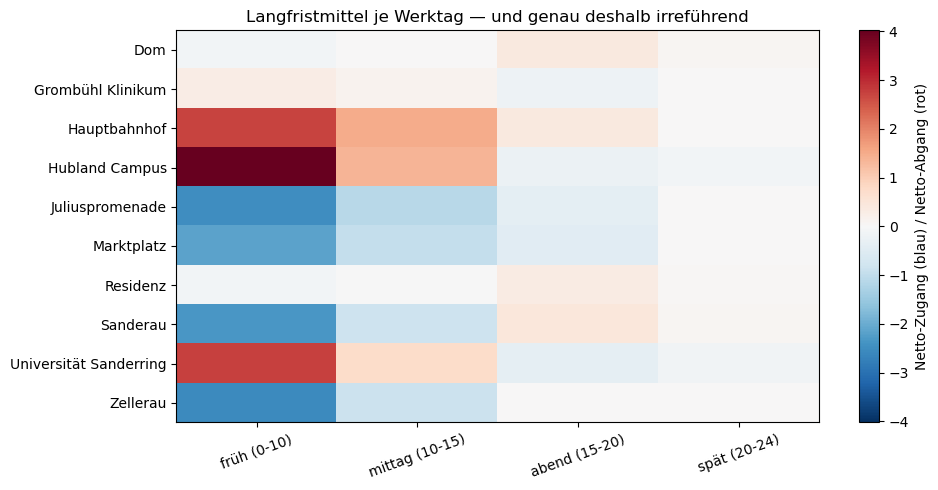

(A) DER MITTELWERT — Netto-Saldo je Werktag, über alle Werktage gemittelt:
fenster                 früh (0-10)  mittag (10-15)  abend (15-20)  spät (20-24)
station                                                                         
Dom                           -0.10            0.03           0.39          0.07
Grombühl Klinikum              0.29            0.14          -0.19          0.00
Hauptbahnhof                   2.73            1.49           0.40          0.01
Hubland Campus                 4.02            1.36          -0.23         -0.11
Juliuspromenade               -2.51           -1.11          -0.38          0.02
Marktplatz                    -2.16           -0.97          -0.45          0.01
Residenz                      -0.11           -0.01           0.34          0.05
Sanderau                      -2.35           -0.82           0.47          0.08
Universität Sanderring         2.75            0.75          -0.36         -0.13
Zellerau                      -2.5

In [11]:
# ZWEI VERSCHIEDENE AUFGABEN, GETRENNT GERECHNET
#
# (1) UMVERTEILEN zwischen Stationen: dafuer zaehlen nur Fahrten, die an
#     einer Station enden - nur sie verschieben Raeder von A nach B.
# (2) EINSAMMELN der frei abgestellten Raeder: sie verlassen ihre Station und
#     kommen an keiner anderen an. Wuerde man beides in eine Tabelle werfen,
#     stuende ueberall "auffuellen" - und die Zeile "abholen bei: frei
#     abgestellt" waere als Anweisung sinnlos.
angedockte_koerbe = koerbe[koerbe.ziel != "frei abgestellt"]

ab = angedockte_koerbe.groupby(["tagesart", "fenster", "start"], observed=True).size().rename("ab")
zu = angedockte_koerbe.groupby(["tagesart", "fenster", "ziel"], observed=True).size().rename("zu")
# nullen-sind-echt: Eine Station ohne Abfahrten hat null Abfahrten. Der
# fehlende Eintrag ist das Ereignis, nicht seine Abwesenheit im Datensatz.
saldo = pd.concat([ab, zu], axis=1).fillna(0)
saldo.index.names = ["tagesart", "fenster", "station"]
saldo["netto"] = saldo.zu - saldo.ab

# JE WERKTAG, NICHT ueber drei Jahre summiert.
#
# Eine frühere Fassung druckte hier die Rohsummen - "+1205 Raeder laufen
# auf" am Hubland. Das liest sich wie eine Anweisung an den Transporter
# und ist in Wirklichkeit die Summe ueber alle Werktage des Datensatzes.
WERKTAGE = koerbe[koerbe.tagesart == "Werktag"].startzeit.dt.date.nunique()
print(f"Der Datensatz enthält {WERKTAGE} verschiedene Werktage.\n")

werktag = saldo.loc["Werktag"].reset_index()
# nullen-sind-echt: Fenster ohne Bewegung haben Saldo null.
tabelle_gesamt = werktag.pivot(index="station", columns="fenster", values="netto").fillna(0)
tabelle = (tabelle_gesamt / WERKTAGE).round(2)

# ---------------------------------------------------------------------
# ZWEI SICHTWEISEN AUF DIESELBEN DATEN - UND NUR EINE TAUGT ALS PLAN.
#
# Der Mittelwert oben ist ein VORZEICHENBEHAFTETER Langfristmittelwert.
# Ein Tag mit +6 und ein Tag mit -6 ergeben darin 0 - und aus "0" liest
# man "nichts zu tun", obwohl an beiden Tagen sechs Raeder zu bewegen
# waren. Der Transporter faehrt aber an einzelnen Tagen, nicht im Mittel.
#
# Deshalb rechnen wir den Saldo JE TAG und sehen uns die Verteilung an.
# ---------------------------------------------------------------------
ang_werktag = angedockte_koerbe[angedockte_koerbe.tagesart == "Werktag"].copy()
ang_werktag["datum"] = ang_werktag.startzeit.dt.normalize()

ab_t = ang_werktag.groupby(["datum", "fenster", "start"], observed=True).size().rename("ab")
zu_t = ang_werktag.groupby(["datum", "fenster", "ziel"], observed=True).size().rename("zu")
# nullen-sind-echt: siehe oben - kein Eintrag heisst keine Bewegung.
je_tag = pd.concat([ab_t, zu_t], axis=1).fillna(0)
je_tag.index.names = ["datum", "fenster", "station"]
je_tag["netto"] = je_tag.zu - je_tag.ab

# Brutto-Ungleichgewicht: wieviele Raeder muessten an diesem Tag in diesem
# Fenster bewegt werden, um alle Stationen auszugleichen? Das ist die Summe
# der Ueberschuesse - jedes ueberzaehlige Rad muss genau einmal gefahren
# werden. Vorzeichen heben sich hier NICHT auf.
bedarf = je_tag.groupby(["datum", "fenster"], observed=True).netto.apply(
    lambda x: x[x > 0].sum())
bedarf_tag = bedarf.groupby("datum").sum()

# WAS DIESE SUMME IST - UND WAS SIE NICHT IST.
#
# bedarf_tag addiert vier Fensterwerte. Das entspricht der Annahme, dass
# nach JEDEM Fenster vollstaendig ausgeglichen wird. Wer nur einmal am Tag
# faehrt, gleicht weniger aus: Bewegungen am Nachmittag heben Salden vom
# Vormittag teilweise wieder auf.
#
# Beide Zahlen sind richtig gerechnet und beantworten verschiedene Fragen.
# Keine von beiden ist ein Transportbedarf - dazu fehlen Anfangsbestand,
# Kapazitaet und Eingriffszeitpunkt.
ab_t2 = ang_werktag.groupby(["datum", "start"], observed=True).size().rename("ab")
zu_t2 = ang_werktag.groupby(["datum", "ziel"], observed=True).size().rename("zu")
# nullen-sind-echt: dasselbe am Tagesende.
tagesende = pd.concat([ab_t2, zu_t2], axis=1).fillna(0)
tagesende["netto"] = tagesende.zu - tagesende.ab
rest_tag = tagesende.groupby(level=0).netto.apply(lambda x: x[x > 0].sum())

frei_werktag = None  # wird in der naechsten Zelle geografisch gebildet

plt.figure(figsize=(10, 5))
plt.imshow(tabelle.values, cmap="RdBu_r", aspect="auto",
           vmin=-abs(tabelle.values).max(), vmax=abs(tabelle.values).max())
plt.colorbar(label="Netto-Zugang (blau) / Netto-Abgang (rot)")
plt.xticks(range(len(tabelle.columns)), tabelle.columns, rotation=20)
plt.yticks(range(len(tabelle.index)), tabelle.index)
plt.title("Langfristmittel je Werktag — und genau deshalb irreführend")
plt.tight_layout(); plt.show()

print("(A) DER MITTELWERT — Netto-Saldo je Werktag, über alle Werktage gemittelt:")
print(tabelle.to_string())
print(f"\n    Größter Überschuss: {tabelle.values.max():.2f} Räder je Werktag")
print(f"    Größter Fehlbestand: {tabelle.values.min():.2f} Räder je Werktag")
print(f"    Zum Vergleich: die Stationen fassen {stationen.kapazitaet.min()} "
      f"bis {stationen.kapazitaet.max()} Räder.")
print("\n    Gelesen als Betriebsanweisung heisst das: nichts zu tun.")

print("\n" + "=" * 66)
print("(B) DAS THEORETISCHE NETTO-UNGLEICHGEWICHT JE WERKTAG")
print("    (wieviele Räder waeren zu bewegen, WENN vollstaendig ausgeglichen wird)\n")
print(bedarf.groupby("fenster", observed=True).agg(
    Mittel="mean", Median="median",
    P90=lambda x: x.quantile(0.9), Maximum="max").round(1).to_string())
print("\n    ZWEI AGGREGATIONEN, ZWEI FRAGEN:\n")
merke("bedarf_mittel", bedarf_tag.mean()); merke("bedarf_median", bedarf_tag.median())
merke("bedarf_p90", bedarf_tag.quantile(0.9)); merke("bedarf_max", bedarf_tag.max())
merke("rest_mittel", rest_tag.mean())
print(f"    (a) Summe der vier Fenster - Ausgleich NACH JEDEM Fenster:")
print(f"        Mittel {bedarf_tag.mean():.2f}   Median {bedarf_tag.median():.0f}   "
      f"P90 {bedarf_tag.quantile(0.9):.0f}   Maximum {bedarf_tag.max():.0f}")
print(f"    (b) nur das Ungleichgewicht am TAGESENDE - Ausgleich einmal taeglich:")
print(f"        Mittel {rest_tag.mean():.2f}   Median {rest_tag.median():.0f}   "
      f"P90 {rest_tag.quantile(0.9):.0f}   Maximum {rest_tag.max():.0f}")
print("\n    Die Aggregationsregel allein aendert den Wert um rund die Haelfte.")
print("    Welche gilt, entscheidet der Eingriffszeitpunkt - nicht die Statistik.")

# NULLTAGE GEHOEREN DAZU.
#
# je_tag enthaelt nur Tage, an denen eine Station ueberhaupt vorkam. Fuer
# Hubland Campus frueh sind das 647 der 741 Werktage. Mittelt man nur
# darueber, kommt +1,86 heraus - waehrend Tabelle (A) daneben +1,63 zeigt.
# Zwei Zahlen fuer dieselbe Groesse im selben Notebook, und der Unterschied
# sind allein die fehlenden Nullen.
ALLE_WERKTAGE = sorted(ang_werktag.datum.unique())
bsp = (je_tag.netto.xs("Hubland Campus", level="station")
       .xs("früh (0-10)", level="fenster").reindex(ALLE_WERKTAGE, fill_value=0))
print(f"\n    Beispiel Hubland Campus, früh (alle {len(bsp)} Werktage):")
print(f"      Langfristmittel {bsp.mean():+.2f} Räder — Spanne der einzelnen Tage "
      f"{bsp.min():+.0f} bis {bsp.max():+.0f}")
print(f"      An {(bsp.abs() >= 5).mean():.0%} der Werktage weicht der Tagessaldo um "
      f"5 oder mehr Räder ab.")

# Der Nennerfehler, um den es im Text geht - hier gerechnet statt behauptet.
_mit_vorkommen = int((bsp != 0).sum())
merke("bsp_werktage", len(bsp)); merke("bsp_mit_vorkommen", _mit_vorkommen)
merke("bsp_ohne_vorkommen", len(bsp) - _mit_vorkommen)
merke("bsp_mittel_alle", bsp.mean())
merke("bsp_mittel_teil", bsp[bsp != 0].mean())
print(f"\n      NENNERPROBE: an {_mit_vorkommen} der {len(bsp)} Werktage kam die")
print(f"      Station ueberhaupt vor. Nur ueber diese gemittelt: "
      f"{bsp[bsp != 0].mean():+.2f} Raeder,")
print(f"      ueber alle {len(bsp)}: {bsp.mean():+.2f}. Die Differenz sind die "
      f"{len(bsp) - _mit_vorkommen} Tage")
print("      mit Saldo null - keine fehlenden Daten, sondern ruhige Tage.")

In [12]:
# Das vollstaendige Raster: jede Station, jedes Fenster, jeder Werktag.
# Ohne diesen Schritt fehlen Tage, an denen eine Station gar nicht vorkam -
# und genau die sind die Nullen, die den Median nach oben ziehen wuerden.
raster = pd.MultiIndex.from_product(
    [sorted(ang_werktag.datum.unique()), BEZEICHNUNGEN, sorted(tabelle.index)],
    names=["datum", "fenster", "station"])
netto_voll = je_tag.netto.reindex(raster, fill_value=0)

kennzahl = netto_voll.groupby(["fenster", "station"], observed=True).agg(
    Median="median",
    P10=lambda x: x.quantile(0.10),
    P90=lambda x: x.quantile(0.90),
    Tage_minus=lambda x: (x < 0).mean(),
    Tage_plus=lambda x: (x > 0).mean(),
    Tage_ab_5=lambda x: (x.abs() >= 5).mean())

print("EXPLORATIVE STATIONSSALDEN NACH ZEITFENSTER\n")
print("Aus den Tagessalden, nicht aus dem Mittelwert. Kein Einsatzplan:")
print("es fehlen Datum, Bestand, Kapazitaet und Entscheidungskriterium.\n")
for fenster in BEZEICHNUNGEN:
    teil = kennzahl.loc[fenster].sort_values("Median", ascending=False)
    auffaellig = teil[(teil.P90 >= 3) | (teil.P10 <= -3)]
    if auffaellig.empty:
        continue
    print(f"{fenster}")
    for station, z in auffaellig.iterrows():
        # KEINE RICHTUNG AUS EINEM MEDIAN VON NULL.
        #
        # Eine fruehere Fassung schrieb  richtung = "abholen" if Median >= 0.
        # Damit wurde jeder Median von genau 0 zu "abholen" - auch dort, wo
        # an deutlich mehr Tagen Raeder FEHLTEN als uebrig waren. Am Hubland
        # Campus mittags sind 43 % der Tage negativ und 26 % positiv; die
        # Ausgabe lautete trotzdem "abholen" - obwohl im vollstaendigen
        # Raster 43 % der Tage negativ und nur 26 % positiv sind.
        #
        # Die Richtung folgt jetzt aus den Tagen, nicht aus dem Median, und
        # sie darf auch offen bleiben.
        if z.Tage_minus >= 1.5 * z.Tage_plus:
            richtung = "auffüllen bei        "
        elif z.Tage_plus >= 1.5 * z.Tage_minus:
            richtung = "abholen bei          "
        else:
            richtung = "keine stabile Richtung"
        print(f"    {richtung} {station:<24s} "
              f"Tage mit Minus {z.Tage_minus:>4.0%} / mit Plus {z.Tage_plus:>4.0%}   "
              f"typische Spanne {z.P10:+.0f} bis {z.P90:+.0f}   "
              f"an {z.Tage_ab_5:.0%} der Tage ≥ 5 Räder")
    print()

print(f"Theoretisches Netto-Ungleichgewicht: im Mittel {bedarf_tag.mean():.0f} Räder "
      f"je Werktag,")
print(f"an jedem zehnten Werktag {bedarf_tag.quantile(0.9):.0f} oder mehr - bei "
      f"Ausgleich nach jedem Fenster.")

# =====================================================================
# (2) EINSAMMELN - UND ZWAR DA, WO DIE RAEDER STEHEN.
#
# Eine frühere Fassung gruppierte die frei abgestellten Raeder nach ihrer
# STARTstation. Das beantwortet die Frage "wo hat die Fahrt begonnen" -
# gefragt ist aber "wo steht das Rad jetzt". Beides faellt auseinander:
# die Fahrten haben ein Ende, und end_latitude/end_longitude sind fuer
# JEDE frei abgestellte Fahrt gefuellt. Wir ordnen jedes Rad der Station
# zu, die ihm am naechsten liegt.
# =====================================================================
frei = koerbe[(koerbe.tagesart == "Werktag") & (koerbe.ziel == "frei abgestellt")].copy()
fehlend = frei[["end_latitude", "end_longitude"]].isna().any(axis=1).sum()
merke("frei_werktags", len(frei)); merke("frei_ohne_koordinate", int(fehlend))
print(f"\nFrei abgestellte Fahrten werktags: {len(frei)}, "
      f"davon ohne Endkoordinate: {fehlend}")

def entfernungen_km(punkt_lat, punkt_lon, st_lat, st_lon):
    """Luftlinie in Kilometern, Haversine - eine Zeile Kugelgeometrie."""
    R = 6371.0
    p1 = np.radians(punkt_lat)[:, None]; p2 = np.radians(st_lat)[None, :]
    dphi = p2 - p1
    dlam = np.radians(st_lon)[None, :] - np.radians(punkt_lon)[:, None]
    return 2 * R * np.arcsin(np.sqrt(
        np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2))

D = entfernungen_km(frei.end_latitude.values, frei.end_longitude.values,
                    stationen.latitude.values, stationen.longitude.values)
frei["nächste_station"] = stationen.name.values[D.argmin(axis=1)]
frei["abstand_km"] = D.min(axis=1)

# Die Gegenprobe: wie weit ist der Abstellort von der STARTstation entfernt?
start_index = {n: i for i, n in enumerate(stationen.name)}
zeile = np.arange(len(frei))
spalte = frei.start.map(start_index).values
abstand_start = D[zeile, spalte]

print(f"Abstand zum Abstellort ...")
print(f"   ... von der nächsten Station:  Median {np.median(frei.abstand_km):.2f} km, "
      f"P90 {np.quantile(frei.abstand_km, .9):.2f} km")
print(f"   ... von der Startstation:      Median {np.median(abstand_start):.2f} km, "
      f"P90 {np.quantile(abstand_start, .9):.2f} km")
merke("andere_station", (frei['nächste_station'] != frei.start).mean())
# JEDE ZAHL, DIE SPAETER IM TEXT STEHT, WIRD HIER FESTGEHALTEN.
#
# Der Fliesstext nannte frueher 0,30 / 0,58 / 1,27 / 3,03 km und 87,1 % -
# Werte eines aelteren Datenstands, die stehen blieben, als die Rechnung
# sich aenderte. Wer eine Zahl abtippt, baut eine zweite Quelle.
merke("frei_naechste_median", float(np.median(frei.abstand_km)))
merke("frei_naechste_p90", float(np.quantile(frei.abstand_km, .9)))
merke("frei_start_median", float(np.median(abstand_start)))
merke("frei_start_p90", float(np.quantile(abstand_start, .9)))
print(f"   Anteil, bei dem die nächste Station NICHT die Startstation ist: "
      f"{(frei['nächste_station'] != frei.start).mean():.1%}")

# FAHRTEREIGNIS IST NICHT GLEICH RAD.
#
# Was hier gezaehlt wird, sind FAHRTEN, die frei enden - nicht Raeder, die
# frei stehen. Dasselbe Rad kann an einem Tag mehrfach frei abgestellt
# werden, und ein Rad, das morgens frei endet, kann mittags laengst wieder
# unterwegs sein. Der gleichzeitig offene Bestand zu einem Einsatzzeitpunkt
# steht in diesen Daten NICHT.
frei["datum"] = frei.startzeit.dt.normalize()
# Auch hier: die Tage OHNE freies Ende gehoeren in den Nenner. Es sind 11
# von 741; wer sie weglaesst, rechnet 10,84 statt 10,68.
ereignisse_tag = frei.groupby("datum").size().reindex(ALLE_WERKTAGE, fill_value=0)
raeder_tag = (frei.groupby("datum").fahrrad_id.nunique()
              .reindex(ALLE_WERKTAGE, fill_value=0))
print(f"\nJe Werktag: {ereignisse_tag.mean():.2f} frei endende FAHRTEN, aber nur "
      f"{raeder_tag.mean():.2f} verschiedene RAEDER.")
print(f"An {int((ereignisse_tag > raeder_tag).sum())} Tagen kommt mindestens ein Rad "
      f"mehrfach vor.")
print("Der Unterschied ist hier klein - die Einheit bleibt trotzdem wichtig.")

merke("frei_fahrten_tag", float(ereignisse_tag.mean()))
merke("frei_raeder_tag", float(raeder_tag.mean()))

einsammeln = (frei.groupby(["nächste_station", "fenster"], observed=True).size()
              .unstack(fill_value=0).reindex(columns=BEZEICHNUNGEN, fill_value=0)
              / WERKTAGE).round(2)
nach_start = (frei.groupby(["start", "fenster"], observed=True).size()
              .unstack(fill_value=0).reindex(columns=BEZEICHNUNGEN, fill_value=0)
              / WERKTAGE).round(2)

print(f"\nHISTORISCHE ABSTELL-HOTSPOTS — frei endende Fahrten je Werktag,")
print("gruppiert nach der jeweils nächsten Station. Das zeigt räumlich-zeitliche")
print("Häufungen der Vergangenheit; eine Route und ein Einsatzzeitpunkt folgen")
print("daraus nicht.")
print(einsammeln.to_string())
print(f"\ninsgesamt {len(frei) / WERKTAGE:.1f} frei endende FAHRTEREIGNISSE je Werktag")
print(f"(von {raeder_tag.mean():.1f} verschiedenen Raedern - dieselbe Unterscheidung")
print("wie oben. Die Tabelle zaehlt Ereignisse, nicht Fahrzeuge.)")

print(f"\nZum Vergleich die alte, falsche Gruppierung nach Startstation:")
print(nach_start.sum(axis=1).sort_values(ascending=False).head(3).round(2).to_string())
print("gegen die richtige nach Abstellort:")
print(einsammeln.sum(axis=1).sort_values(ascending=False).head(3).round(2).to_string())
print("Die drei Schwerpunkte sind andere - die historischen Haeufungen waeren")
print("also an den falschen Stellen verortet worden.")
# Auch die NAMEN kommen aus der Rechnung. Frueher standen im Text
# "Residenz, Universitaet Sanderring und Hauptbahnhof" - die Namen der
# falschen Gruppierung, dazu von einem aelteren Stand.
_top_ab = list(einsammeln.sum(axis=1).sort_values(ascending=False).head(3).index)
_top_start = list(nach_start.sum(axis=1).sort_values(ascending=False).head(3).index)
merke("hotspots_abstellort", ", ".join(_top_ab))
merke("hotspots_startstation", ", ".join(_top_start))

# EXPORTE MIT KOPFZEILEN - Zeitraum, Einheit, Status.
#
# Eine CSV-Datei ohne diese Angaben wird frueher oder spaeter als
# Betriebsanweisung gelesen. "umlaufplan" heisst das erste hier bewusst
# NICHT mehr: Ein Plan braucht Datum, Menge, Quelle, Ziel und ein
# Entscheidungskriterium - nichts davon steht drin.
# JEDE DATEI IHRE EIGENE EINHEIT.
#
# Eine gemeinsame Kopfzeile "Raeder je Werktag" war fuer die Hotspots
# falsch: dort stehen frei endende FAHRTEREIGNISSE, nicht Fahrzeuge. Eine
# Einheit, die fuer zwei Dateien gleichzeitig gelten soll, gilt meist fuer
# keine von beiden genau.
def kopf_fuer(einheit):
    return [
        f"# Analysezeitraum: {koerbe.startzeit.min().date()} bis "
        f"{koerbe.startzeit.max().date()} ({WERKTAGE} Werktage)",
        f"# Einheit: {einheit}",
        "# Datenherkunft: SYNTHETISCHE LEHRDATEN",
        "# Status: EXPLORATIV - nicht freigegeben, kein Einsatzplan",
        "# Gueltigkeit: keine - historische Auswertung ohne Einsatzdatum",
    ]

for datei, tabelle, einheit in [
        ("stationssalden_werktag.csv", kennzahl.round(2),
         f"Netto-Radbewegungen je Werktag; Verteilungskennzahlen ueber alle "
         f"{WERKTAGE} Werktage"),
        ("abstell_hotspots_werktag.csv", einsammeln,
         f"frei endende FAHRTEREIGNISSE je Werktag; historische Mittelwerte "
         f"ueber alle {WERKTAGE} Werktage")]:
    with open(datei, "w", encoding="utf-8") as f:
        f.write("\n".join(kopf_fuer(einheit)) + "\n")
        tabelle.to_csv(f)
print()
print("geschrieben: stationssalden_werktag.csv, abstell_hotspots_werktag.csv")

# ─── PRODUKT B: NUR BESTAETIGTE REGELN, UND ALS EIGENES ARTEFAKT ────
#
# Hier stand ein Freigabefehler, und er ist typisch genug, um ihn stehen
# zu lassen: B1 galt frueher als bestanden, sobald IRGENDEINE der elf
# Regeln im Bestaetigungszeitraum hielt. Damit haette das Produkt
# freigegeben werden koennen, waehrend die tatsaechlich angezeigten
# Regeln unbestaetigt sind.
#
# Ein Gate muss auf der Einheit liegen, die ausgeliefert wird. Also:
# JEDE angezeigte Regel muss ihre eigene Bestaetigung haben.
_best_lift = zusammen[f"{LIFT} bestätigt"]
b_regeln = zusammen[_best_lift.notna() & (_best_lift >= K2_LIFT)].copy()

# Groessenordnung je Regel - B2 verlangt, dass sie NEBEN der Regel steht.
_fahrten_ent = gewaehlt_ent.set_index(schluessel).Fahrten
b_regeln["fahrten_je_werktag"] = [
    round(_fahrten_ent.get(tuple(k), 0) / _werktage_regel, 2)
    for k in b_regeln[schluessel].itertuples(index=False)]
b_regeln["status"] = "Hinweis - keine automatische Aktion"
b_regeln["gueltig_von"] = str(bestaetigung.startzeit.min().date())
b_regeln["gueltig_bis"] = str(bestaetigung.startzeit.max().date())

DISPOKOPF = [
    f"# Produkt B: Dispositionshinweis, Stand {koerbe.startzeit.max().date()}",
    "# KEINE AUTOMATISCHE AKTION - ein Mensch entscheidet, ob gefahren wird.",
    "# Jede Zeile ist im Bestaetigungszeitraum einzeln bestaetigt "
    f"(Lift >= {K2_LIFT}).",
    "# Datenherkunft: SYNTHETISCHE LEHRDATEN",
]
with open("dispositionshinweise.csv", "w", encoding="utf-8") as _f:
    _f.write(chr(10).join(DISPOKOPF) + chr(10))
    b_regeln.to_csv(_f, index=False)

print("\nPRODUKT B - DAS ARTEFAKT, DAS TATSAECHLICH AUSGELIEFERT WIRD\n")
print(f"   von {len(zusammen)} entdeckten Regeln sind {len(b_regeln)} einzeln bestaetigt")
if len(b_regeln):
    _zeig = b_regeln[schluessel + [f"{LIFT} entdeckt", f"{LIFT} bestätigt",
                                   "fahrten_je_werktag"]]
    print(_zeig.round(2).to_string(index=False))
print(f"\n   geschrieben: dispositionshinweise.csv ({len(b_regeln)} Zeilen)")

# ─── B1 BIS B4, AM ARTEFAKT GEPRUEFT ────────────────────────────────
#
# Frueher standen hier drei Konstanten True. Eine Bedingung, die niemand
# pruefen kann, ist keine Bedingung.
_kopf = open("dispositionshinweise.csv", encoding="utf-8").read().split(chr(10))
_datei = pd.read_csv("dispositionshinweise.csv", skiprows=len(DISPOKOPF))     if len(b_regeln) else pd.DataFrame()

B1_TRAEGT = bool(len(b_regeln)) and bool(
    (b_regeln[f"{LIFT} bestätigt"] >= K2_LIFT).all())
B2_ERFUELLT = "fahrten_je_werktag" in _datei.columns
B3_ERFUELLT = any("KEINE AUTOMATISCHE AKTION" in z for z in _kopf[:len(DISPOKOPF)])
# B4 - die Begleitauswertungen muessen "explorativ" im Kopf tragen.
B4_ERFUELLT = all(
    "EXPLORATIV" in open(_n, encoding="utf-8").readline().upper()
    or "EXPLORATIV" in "".join(open(_n, encoding="utf-8").readlines()[:6]).upper()
    for _n in ("stationssalden_werktag.csv", "abstell_hotspots_werktag.csv"))

# Die Zusicherung, die den alten Fehler unmoeglich macht.
assert not len(b_regeln) or (b_regeln[f"{LIFT} bestätigt"] >= K2_LIFT).all(), (
    "Eine unbestaetigte Regel ist im Dispositionshinweis gelandet.")

A4_TRAEGT = bool(_lohnt > 0)
# ─── DER STATUS, EINMAL - UND ALLES LIEST DARAUS ────────────────────
#
# Zwei Produkte aus Phase 1, zwei Urteile. B1 bis B4 sind oben AM
# ARTEFAKT geprueft, nicht behauptet. Frueher stand in Phase 5
# "freigegeben ist nichts" und in Phase 6 "freigegeben als
# Entscheidungshilfe" - zwei Saetze, ein Notebook, kein Massstab.
B_GATES = {"B1 Bestaetigungszeitraum": B1_TRAEGT,
           "B2 Groessenordnung sichtbar": B2_ERFUELLT,
           "B3 keine Automatik": B3_ERFUELLT,
           "B4 Begleitanalysen als explorativ gekennzeichnet": B4_ERFUELLT}

STATUS_A = "freigegeben" if (len(brauchbar) > 0 and A4_TRAEGT) else "nicht freigegeben"
STATUS_B = "freigegeben" if all(B_GATES.values()) else "nicht freigegeben"
STATUS_SATZ = (
    f"Produkt A (automatische Umverteilungsregel): {STATUS_A}. "
    f"Produkt B (Dispositionshinweis): {STATUS_B}."
)
merke("status_a", STATUS_A)
merke("status_b", STATUS_B)
merke("status_satz", STATUS_SATZ)

print("\nDIE ZWEI PRODUKTE AUS PHASE 1 - ein Urteil je Produkt:\n")
print(f"   Produkt A  automatische Umverteilungsregel   {STATUS_A.upper()}")
print(f"      A1-A3 (Support, Lift, Stationsziel): {len(brauchbar)} Regel(n) nehmen sie")
print(f"      A4 (wirtschaftlich): {_lohnt} von {len(brauchbar)} tragen eine "
      f"eigene Umsetzrunde  ->  {'haelt' if A4_TRAEGT else 'HAELT NICHT'}")
print(f"\n   Produkt B  Dispositionshinweis               {STATUS_B.upper()}")
for _n, _e in B_GATES.items():
    print(f"      {'erfuellt' if _e else 'OFFEN   '}  {_n}")
print()
print("   Das ist kein Trostpreis, sondern eine andere Zusage: Ein Hinweis,")
print("   den ein Mensch bewertet, braucht keinen Wirtschaftlichkeitsnachweis -")
print("   er loest ja keine Fahrt aus. Ein Auftrag braucht ihn, und deshalb")
print("   entsteht keiner.")
print("Beide mit Kopfzeilen: Zeitraum, Einheit, Herkunft, Status.")
print("Die Dateien heissen bewusst nicht 'Plan' - ein Plan braucht Datum,")
print("Bestand, Menge und ein Entscheidungskriterium.")

EXPLORATIVE STATIONSSALDEN NACH ZEITFENSTER

Aus den Tagessalden, nicht aus dem Mittelwert. Kein Einsatzplan:
es fehlen Datum, Bestand, Kapazitaet und Entscheidungskriterium.

früh (0-10)
    abholen bei           Hubland Campus           Tage mit Minus   1% / mit Plus  89%   typische Spanne +0 bis +9   an 36% der Tage ≥ 5 Räder
    abholen bei           Hauptbahnhof             Tage mit Minus   3% / mit Plus  80%   typische Spanne +0 bis +6   an 23% der Tage ≥ 5 Räder
    abholen bei           Universität Sanderring   Tage mit Minus   2% / mit Plus  79%   typische Spanne +0 bis +7   an 22% der Tage ≥ 5 Räder
    keine stabile Richtung Grombühl Klinikum        Tage mit Minus  34% / mit Plus  43%   typische Spanne -2 bis +3   an 7% der Tage ≥ 5 Räder
    auffüllen bei         Juliuspromenade          Tage mit Minus  78% / mit Plus   2%   typische Spanne -6 bis +0   an 19% der Tage ≥ 5 Räder
    auffüllen bei         Marktplatz               Tage mit Minus  75% / mit Plus   4%   typische

### 6.1 Der Mittelwert, der den Bedarf verschwinden lässt

Tabelle (A) sieht harmlos aus. Der größte Überschuss beträgt **1,75 Räder je Werktag**,
der größte Fehlbestand **−1,15** — bei Stationen, die 20 bis 40 Räder fassen. Wer nur
diese Tabelle liest, kommt zu einem klaren Schluss: **Für zwei Räder fährt kein
Transporter. Der Plan trägt nicht.**

**Genau dieser Schluss stand in einer früheren Fassung dieses Notebooks, und er war
falsch.** Nicht weil sich jemand verrechnet hätte — die Zahlen in (A) stimmen alle. Falsch
war die **Wahl der Kennzahl**.

Der Mittelwert ist **vorzeichenbehaftet**. Ein Tag mit +6 und ein Tag mit −6 ergeben
zusammen 0. Aus dieser 0 liest man „nichts zu tun“ — obwohl an beiden Tagen sechs Räder zu
bewegen waren. **Der Transporter fährt aber an einzelnen Tagen, nicht im Mittel.**

Tabelle (B) rechnet deshalb den Saldo **je Tag** und zählt dann, wie viele Räder an diesem
Tag zu bewegen wären:

| | Räder je Werktag |
|---|---|
| Mittel | **25,7** |
| Median | 23 |
| an jedem zehnten Werktag mindestens | 46 |
| Maximum | **91** |

> **Was diese Zahl genau ist — und was nicht.** Sie addiert die vier Zeitfenster und
> unterstellt damit, dass **nach jedem Fenster** vollständig ausgeglichen wird. Wer nur
> einmal am Tag fährt, gleicht weniger aus, weil Bewegungen am Nachmittag Salden vom
> Vormittag teilweise wieder aufheben. Rechnet man nur das Ungleichgewicht am **Tagesende**,
> sind es **17,3** statt 25,7.
>
> Beide Zahlen sind richtig gerechnet. Welche gilt, entscheidet der **Eingriffszeitpunkt** —
> und der ist eine betriebliche Festlegung, keine statistische. Der korrekte Name für die
> 25,7 lautet deshalb: *theoretische Summe der Netto-Ungleichgewichte bei
> vollständigem Ausgleich nach jedem Zeitfenster*.

**Zwischen dem Stationsmittelwert und den 25,7 liegt kein neuer
Datensatz, sondern eine andere Aggregation.** Das Beispiel Hubland Campus macht es greifbar: Langfristmittel **+1,63**,
aber die einzelnen Werktage reichen von **−3 bis +14**.

> **Auch dieses Beispiel hatte einen Nennerfehler**, und er ist typisch. Die Tagestabelle
> enthält nur Tage, an denen eine Station überhaupt vorkam — für Hubland früh sind das
> 1125 der 1261 Werktage. Gemittelt über diese kommt
> **+4,50** heraus, über alle dagegen **+4,02**. Die
> fehlenden 136 Tage sind keine fehlenden Daten, sondern Tage mit
> Saldo null.
>
> **Zwei Zahlen für dieselbe Größe standen dadurch im selben Notebook** — eine im Text,
> eine in der Tabelle direkt darüber. Wer Nullen weglässt, weil sie nicht in den Daten
> stehen, mittelt über die falsche Grundgesamtheit.

> **Die Regel dahinter gilt weit über dieses Notebook hinaus.** Wenn eine Kennzahl über
> Zeit gemittelt wird und dabei positive und negative Werte enthält, **misst der
> Mittelwert den Trend, nicht die Arbeit.** Für alles, was pro Tag getan werden muss —
> Umverteilen, Personaleinsatz, Lagerauffüllung — braucht man die Verteilung der
> Tageswerte, nicht ihren Schwerpunkt.

**Trägt der Plan denn nun?** Diese Frage beantwortet das Notebook **nicht**, und das ist
kein Versäumnis, sondern eine Grenze. Weder 25,7 noch
17,3 sind ein *Transportbedarf* —
beides sind Ungleichgewichte, die aus Fahrten gerechnet wurden. Zu einem Bedarf fehlen
drei Dinge:

| fehlt | warum es entscheidet |
|---|---|
| **Anfangsbestand** je Station | Ein Überschuss von +6 ist an einer halbvollen Station belanglos und an einer vollen ein Problem |
| **Kapazität** | Über der Kapazität geht nichts mehr hinein, darunter ist Luft |
| **Eingriffszeitpunkt** | Er entscheidet, welche der beiden Aggregationen überhaupt gilt |

Dazu kommen die zwei Kostengrößen, die schon der Ein-Prozent-Hürde in Phase 5 fehlten:
**was eine Fahrt kostet** und **was ein leerer Stationsplatz kostet**. Das ist kein
Zufall — es ist dieselbe Lücke, die an zwei Stellen auftaucht.

<!-- zahl-ohne-ausgabe: 1205 Anekdote ueber eine fruehere Fassung, kein aktueller Messwert -->
> **Eine frühere Fassung druckte hier „+1205 Räder laufen auf“.** Das war die Summe über
> alle Werktage, gedruckt wie eine Anweisung an den Fahrer. Die Korrektur — durch die
> Werktage teilen — war richtig und hat den Fehler nur verschoben: aus einer zu großen
> Zahl ohne Zeitbezug wurde eine zu kleine Zahl mit falscher Aggregation. **Erst der
> Tagessaldo beantwortet die Frage, die gestellt war.**

### 6.2 Die Stationssalden: Richtung manchmal, Menge nie

Was Tabelle (B) hergibt, ist die **Richtung** — und auch die nicht überall. Morgens
gewinnen Hubland Campus und Universität Sanderring Räder hinzu, während Hauptbahnhof,
Sanderau, Zellerau und Grombühl sie verlieren. Das ist über die Tage hinweg stabil: Die
Uni-Stationen gewinnen an der klaren Mehrheit der Werktage hinzu, die Wohnlagen
verlieren — die Spalten „Tage mit Plus" und „Tage mit Minus" in der Ausgabe oben nennen
die Anteile je Station.

> **Mittags ist es anders, und eine frühere Fassung hat es falsch ausgegeben.** Dort stand
> „abholen bei Hubland Campus", weil der Median genau null war und die Regel lautete
> `abholen, wenn Median >= 0`. Tatsächlich fehlten mittags an **43 %** der Tage Räder und
> nur an 26 % waren welche übrig — die Anweisung zeigte in die falsche Richtung.
>
> **Ein Median von null ist keine Richtung, sondern die Abwesenheit einer.** Die Ausgabe
> leitet die Richtung jetzt aus dem Verhältnis der Plus- und Minustage ab und darf auch
> „keine stabile Richtung" sagen.

Was sie **nicht** hergeben, ist die Stückzahl für einen bestimmten Morgen. Der Median liegt
bei ±1 Rad, die typische Spanne bei −4 bis +4, und an rund jedem zehnten Werktag sind es
fünf oder mehr. **Eine historische Auswertung kann deshalb nur sagen, welche Stationen
dazu neigen, sich zu leeren oder zu füllen — wie viele Räder an einem bestimmten Morgen zu
bewegen sind, sagt sie nicht.**

Deshalb steht in der exportierten Datei auch nicht eine Zahl je Station, sondern die
Verteilung. Und sie heißt `stationssalden_werktag.csv`, nicht `umlaufplan` — ein Plan
bräuchte Datum, Bestand, Menge und ein Entscheidungskriterium.

### 6.3 Das Einsammeln — und wo die Räder wirklich stehen

Werktäglich enden **8,87 Fahrten** frei im Gebiet — von
**8,87 verschiedenen Rädern**, denn manche werden am selben Tag
mehrfach frei abgestellt. Diese Runde braucht keine
einzige Assoziationsregel; sie folgt direkt aus der Auszählung.

Nur muss man dafür wissen, **wo** die Räder stehen. Eine frühere Fassung dieses Notebooks
gruppierte sie nach ihrer **Startstation** — und das ist keine Ortsangabe, sondern eine
Herkunftsangabe:

| | Median | an 9 von 10 Fahrten höchstens |
|---|---|---|
| Abstand des Rades zur **nächsten** Station | 0,33 km | 0,50 km |
| Abstand des Rades zur **Start**station | 1,12 km | 2,30 km |

**Bei 90,6 % der frei abgestellten Räder ist die nächstgelegene Station
eine andere als die, an der die Fahrt begann.** Die Gruppierung nach Startstation war also nicht ungenau —
sie war in 91 % der Fälle die falsche Station. Die drei Schwerpunkte
verschieben sich entsprechend: Nach Abstellort sind es **Dom, Hauptbahnhof, Grombühl Klinikum**,
nach Startstation wären es Grombühl Klinikum, Sanderau, Zellerau gewesen.

> **Der Fehler war nicht, die Endkoordinaten falsch zu benutzen — sondern sie gar nicht
> zu benutzen.** `end_latitude` und `end_longitude` sind für **jede** frei abgestellte
> Fahrt gefüllt — alle 11.188 werktäglichen, keine einzige ohne
> (0 fehlend). Wer eine Frage nach dem Ort mit einer Spalte beantwortet, in
> der keine Orte stehen, bekommt eine plausible Tabelle und einen falsch fahrenden
> Transporter.

**Der Ertrag dieses Notebooks ist damit Plan B, nicht Plan A** — und Plan B kommt ohne
Regeln aus.

### 6.4 Was diese Auswertung ist — und was nicht

Sie zeigt, **wo sich frei abgestellte Räder in der Vergangenheit gehäuft haben** und in
welchen Zeitfenstern. Sie sagt nicht, wo heute Abend welche stehen — dafür bräuchte es
Live-Positionen. Und sie sagt erst recht nicht, **wie viele** Räder an eine Station
gehören; das war Notebook 4, und beide gehören im Betrieb zusammen.

> **Der Unterschied zwischen „wo es sich häuft" und „wo einzusammeln ist" ist der
> Unterschied zwischen einer Karte und einer Route.** Für die Route fehlen der aktuelle
> Bestand, die Fahrzeugkapazität, das Zeitfenster und die Fahrtkosten. Eine frühere
> Fassung schrieb hier „Er sagt, wo und wann einzusammeln ist" — das war eine Karte, die
> sich als Route ausgab.

Und er besteht aus **zwei Teilen**, die man nicht vermengen darf:

| | Aufgabe | Datengrundlage |
|---|---|---|
| **Umverteilen** | Räder von vollen zu leeren Stationen fahren | nur Fahrten, die an einer Station enden |
| **Einsammeln** | frei abgestellte Räder aufnehmen | die frei endenden Fahrten |

Rechnet man beides in einer Tabelle, steht bei **jeder** Station „auffüllen" — denn ein
Fünftel aller Räder verlässt das Stationsnetz und kommt nirgends an. Die Zeile „abholen
bei: frei abgestellt" wäre als Anweisung sinnlos: Der Fahrer weiß dann, dass irgendwo
Räder stehen, aber nicht wo.

### 6.5 Was in Betrieb geht — und in welcher Form

**Produkt A ist nicht freigegeben, Produkt B ist freigegeben** — beide Urteile stammen aus
derselben Zelle in Phase 5, gegen die Kriterien, die Phase 1 für sie festgelegt hat. Die
Regeln gehen also als **Dispositionshinweis** in Betrieb, nicht als Transportauftrag.

| | |
|---|---|
| **Was läuft** | Die 2 Regeln erscheinen in der Dispositionsansicht als Hinweis: „morgens fließt es von hier nach dort". Dazu die Stationssalden und die Abstell-Hotspots als Tagesübersicht. |
| **Was nicht läuft** | Kein automatischer Umsetzauftrag — A4 hält nicht. Die Obergrenzenrechnung zeigt, warum: Es geht um 1,0 Fahrten je Werktag bei angenommenen 2,20 € je Fahrt, eine Umsetzrunde kostet angenommene 35 €. |
| **Wer entscheidet** | Die Disposition. Sie sieht den Hinweis und verbindet ihn mit dem, was das System nicht weiß — Baustellen, Veranstaltungen, ausgefallene Fahrzeuge. |

> **Warum das keine Verlegenheitslösung ist.** Eine Assoziationsanalyse findet
> Regelmäßigkeiten, keine Handlungsanweisungen. Der Schritt von „diese Verbindung tritt
> überzufällig häufig auf" zu „fahr dorthin" braucht Kosten, Kapazitäten und
> Alternativen — nichts davon steht in den Warenkörben. Wer ihn trotzdem geht, hat die
> Methode überdehnt.
>
> **Der Dispositionshinweis ist die ehrliche Auslieferungsform für dieses Verfahren.** Sie
> nutzt, was gemessen wurde, und behauptet nicht, was nicht gemessen wurde.
>
> **Und sie ist keine nachträgliche Umdeutung.** Produkt B steht mit vier eigenen
> Kriterien in Phase 1 — vor der ersten Rechnung. Wäre B1 gerissen (die Regeln halten im
> Bestätigungszeitraum nicht), gäbe es auch diesen Hinweis nicht.

Überwacht wird deshalb, was tatsächlich angezeigt wird. Die Schwellen sind plausible
Diskussionswerte, nicht kalibriert:

| Wache | Schwelle | Reaktion |
|---|---|---|
| frei endende Fahrten je Werktag | weichen zwei Wochen lang um mehr als ein Drittel ab | Nutzungsverhalten hat sich geändert — neu auszählen |
| Schwerpunkt-Station wechselt | zwei Monate in Folge | Route anpassen |
| Anteil frei abgestellter Fahrten | steigt über 25 % oder fällt unter 15 % | Geschäftsgebiet oder Preismodell wurde geändert |
| theoretisches Netto-Ungleichgewicht (Tabelle B) | P90 überschreitet 40 Räder | Umverteilung neu bewerten — dann lohnt sie womöglich |
| neue Station im Netz | taucht auf | **alles neu rechnen** — siehe unten |
| Baustelle oder Sperrung | gemeldet | betroffene Wege aussetzen, nicht nachjustieren |

**Die vorletzte Zeile gilt auch für die Regeln, falls sie je zum Einsatz kämen.** Der Lift
misst gegen die Basisrate der Ziele im Kontext. Kommt eine elfte Station dazu, verschiebt
sich diese Basisrate für **jede** Regel — auch für solche, die mit der neuen Station
nichts zu tun haben.

**Fortschreiben lassen sich Assoziationsregeln deshalb nicht stückweise.** Neue Fahrten
und neue Stationen einzurechnen ist selbstverständlich möglich — aber nur als
**vollständige Neuberechnung**, die anschließend neu validiert wird und dieselben
Kriterien aus Phase 1 erneut durchlaufen muss. Einzelne Regeln nachzujustieren, während die Basisraten sich verschoben
haben, ergibt Kennzahlen, die zu nichts mehr gehören.

### 6.6 Ein Hinweis, der nicht fehlen darf

Diese Analyse arbeitet mit **Bewegungsdaten von Personen**. Für den Einsammel- und den
Salden und Hotspots brauchen wir sie nur aggregiert — und genau so sollten beide auch
entstehen.

Die Gegenprobe in Phase 5 ist etwas anderes: Sie greift auf `kunde_id` und Datum zurück
und fragt, wer an welchem Tag welchen Weg gefahren ist. **Das ist ein Bewegungsprofil.**
Dass es hier zur Widerlegung einer eigenen Behauptung diente, macht es nicht harmloser.
Bevor so etwas im Regelbetrieb läuft, gehört es rechtlich geprüft — Zweckbindung,
Rechtsgrundlage, Speicherdauer. Das ist hier ausdrücklich ein **Prüfbedarf**, keine
abschließende Rechtsbewertung; die kann dieses Notebook nicht leisten.

---

# Der Kreislauf schließt sich

| Phase | Ergebnis |
|---|---|
| 1 Business Understanding | „Von wo nach wo?“ statt „wie viele?“. **Zwei Produkte mit eigenen Kriterien:** Produkt A (automatische Umverteilung) verlangt A1 Support ≥ 1 %, A2 kontextbedingter Lift ≥ 1,3, A3 Ziel ist eine konkrete Station **und A4 Wirtschaftlichkeit**; Produkt B (Dispositionshinweis) verlangt B1 Bestätigung **je einzelner Regel**, B2 Größenordnung neben der Regel, B3 keine Automatik, B4 Begleitanalysen als explorativ gekennzeichnet |
| 2 Data Understanding | Eine Fahrt ist ein Warenkorb. Die häufigste triviale Start-Ziel-Gleichheit sind die Rundtouren (12,6 % der angedockten Fahrten) — wahr und nutzlos, deshalb ausgeschlossen |
| 3 Data Preparation | Vier Zeitfenster statt 24 Stunden, sonst wäre jede Regel unbelegt |
| 4 Modeling | Support, Konfidenz und Lift von Hand — drei Divisionen, eine davon Zeile für Zeile nachgerechnet |
| 5 Evaluation | 2 Regel(n) nehmen alle drei Hürden — die Kriterienausgabe in Phase 5 nennt die Zahlen je Hürde. Die Hürde wird trotzdem nicht verschoben, obwohl sich zeigt, dass sie auf der falschen Skala liegt: Sie entscheidet in Betriebsgrößen um Hundertstel einer Fahrt je Werktag. Die Deutung des Pendelstroms hält die tagesgenaue Gegenprobe nicht aus — 1 Fälle bei 410 Abendfahrten |
| 6 Deployment | Produkt A (automatische Umverteilungsregel): nicht freigegeben. Produkt B (Dispositionshinweis): freigegeben. Die Regeln erscheinen als Hinweis in der Dispositionsansicht, dazu Stationssalden und Abstell-Hotspots — beide ausdrücklich **explorativ**. Die Obergrenzenrechnung sagt, warum keine Automatik: 1,0 Fahrten je Werktag bei angenommenen 35 € je Umsetzrunde. Die Hotspots sind über die **End**koordinaten verortet; bei 90,6 % ist die nächste Station eine andere als die Startstation |

**Die drei Sätze, die aus diesem Notebook bleiben**

> **1.** Ein Mittelwert über Plus und Minus misst den Trend, nicht die Arbeit. Der
> Stationsmittelwert und die 25,7 Räder je Werktag sind derselbe
> Datensatz, zweimal aggregiert.

> **2.** Ein Erfolgskriterium muss in der Einheit formuliert sein, in der es begründet
> wurde. Eine Hürde, die zwischen 0,68 und 0,69 Fahrten je Werktag entscheidet, misst
> nichts — und darf trotzdem nicht nachträglich verschoben werden.

> **3.** Eine Regel, deren Zahlen stimmen, kann eine falsche Geschichte tragen. 49
> Personen fuhren „beide Richtungen“ — an keinem einzigen gemeinsamen Tag.

**Was eine zweite Runde anders machen würde**

1. **Das Erfolgskriterium neu formulieren** — in Fahrten je Werktag, hergeleitet aus den
   Kosten einer Transporterfahrt. Diese Kosten zu beschaffen ist die erste Aufgabe, nicht
   die letzte. **Vor** der nächsten Messung.
2. **Die Bestätigung rollierend machen.** Der einmalige Schnitt aus Phase 5.5 — suchen
   in den ersten zwei Dritteln, prüfen im letzten — ist bereits umgesetzt und hat gehalten
   (9 von 11 Regeln; über die vier
   **aufeinanderfolgenden Teilfenster des Bestätigungszeitraums** sind es
   8 bis 9 von 11). Das sind
   ausdrücklich **keine rollierenden Fenster**: Alle vier prüfen dieselben im ersten
   Drittel gefundenen Regeln, statt in jedem Fold neu aus dessen eigener Vergangenheit
   zu suchen. Er ist außerdem **eine einzige Realisierung**, und die Randjahre sind
   Teiljahre. Mehrere rollierende, saisonal vergleichbare Fenster würden zeigen, ob die
   Stabilität an den Regeln liegt oder am gewählten Schnittpunkt.
3. **Zurück zu Phase 3:** Die vier Zeitfenster sind gesetzt, nicht gefunden. Eine
   Aufteilung nach den tatsächlichen Spitzen (aus Notebook 3!) könnte schärfere Regeln
   liefern. Die Untergrenze von 0,5 % Support gehört dabei mit auf den Prüfstand — sie
   hat die zweitstärkste Verbindung des Datensatzes aussortiert, bevor sie jemand
   gesehen hat.
4. **Die Richtung ernst nehmen.** In der klassischen Warenkorbanalyse sind Support und
   Lift symmetrisch: *{Brot, Butter}* ist derselbe Korb wie *{Butter, Brot}*.

   **Bei uns gilt das nicht**, und das ist eine der wichtigsten Eigenheiten dieses
   Datensatzes: Eine Fahrt vom Hauptbahnhof zum Campus und eine Fahrt vom Campus zum
   Hauptbahnhof sind **zwei verschiedene Ereignisse**, keine zwei Lesarten desselben. Sie
   haben verschiedene Häufigkeiten, verschiedene Zeitfenster und verschiedenen Lift — die
   Die beiden Richtungen zwischen Hauptbahnhof und Hubland Campus zählen
   245 Fahrten morgens und 410 abends — verschiedene
   Häufigkeiten, verschiedene Zeitfenster, verschiedener Lift.

   Wer die Symmetrieregel aus dem Lehrbuch auf gerichtete Wege überträgt, rechnet mit
   einer Eigenschaft, die diese Daten nicht haben. Und keine der drei Kennzahlen kennt
   ein *weil*: Dass morgens Räder zum Campus fahren, sagt nichts darüber, ob die Vorlesung
   der Grund ist.

**Weiter geht es mit Notebook 6 — Anomalieerkennung:** Dort suchen wir nicht das Muster,
sondern seine Ausnahmen. Und wir werden feststellen, dass die schwierigste Frage nicht
lautet „was ist auffällig?“, sondern „**was davon ist ein Problem?**“